## Step 0 — Libraries

In [ ]:
import os, warnings, random as _random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2 as _l2
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
GPU: True


## Step 1 — Load Data

Mount Google Drive and load the two enriched CSV files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/Colab Notebooks'
print('Files:', sorted(os.listdir(FOLDER)))


Mounted at /content/drive
Files: ['Classification.ipynb', 'Copy_of_Fine_tuning_Antonymes.ipynb', 'Fine_Tuning_synonymes (1).ipynb', 'MCTNet_Arkansas_2021_enriched.csv', 'MCTNet_Arkansas_2021_enriched_fixed.csv', 'MCTNet_California_2021_enriched.csv', 'MCTNet_California_2021_enriched_fixed.csv', 'MCTNet_Full_Pipeline_Part3_FIXED (3).ipynb', 'MCTNet_Full_Pipeline_Part3_FIXED.ipynb', 'NeurNetworks-Project-Part1.ipynb', 'NeurNetworks_Part2_Ablation_FIXED_v2.ipynb', 'NeurNetworks_Part3_GRU_IMPROVED(1).ipynb', 'NeurNetworks_Part3_GRU_IMPROVED.ipynb', 'Part_1_final.ipynb', 'Projet Res Neur.ipynb', 'Untitled', 'Untitled (1)', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled3.ipynb', 'ablation_arkansas.csv', 'ablation_arkansas_part2.csv', 'ablation_arkansas_part3_improved.csv', 'ablation_california.csv', 'ablation_california_part2.csv', 'ablation_california_part3_improved.csv', 'ablation_combined.csv', 'ablation_combined_part2.csv', 'ablation_combined_part3_improved.csv', 'antonymes qwen 2.5 7B_

In [ ]:
df_ar = pd.read_csv(os.path.join(FOLDER, 'MCTNet_Arkansas_2021_enriched_fixed.csv'))
df_ca = pd.read_csv(os.path.join(FOLDER, 'MCTNet_California_2021_enriched_fixed.csv'))


BANDS       = ['Blue', 'Green', 'NIR', 'RE1', 'RE2', 'RE3', 'RE4', 'Red', 'SWIR1', 'SWIR2']
N_TIMESTEPS = 36
N_BANDS     = 10
N_VI        = 4
N_INPUT_BANDS = N_BANDS + N_VI

SPEC_COLS  = [f'{b}_t{t:02d}' for t in range(1, N_TIMESTEPS+1) for b in BANDS]
VALID_COLS = [f'valid_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]


CLIM_BANDS = ['clim_temp_mean_C', 'clim_precip_sum_m', 'clim_dewpoint_mean_C']
CLIM_COLS  = [f'{b}_t{t:02d}' for b in CLIM_BANDS for t in range(1, N_TIMESTEPS+1)]

SOIL_COLS  = ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
TOPO_COLS  = ['topo_elevation_m', 'topo_landform_class']

COVAR_NUM  = CLIM_COLS + ['soil_organic_carbon_g_kg', 'soil_pH', 'topo_elevation_m']
COVAR_CAT  = ['soil_texture_class', 'topo_landform_class']
ALL_COVARS = COVAR_NUM + COVAR_CAT


CLIM_DISPLAY = {'clim_temp_mean_C': 'mean', 'clim_precip_sum_m': 'sum',
                'clim_dewpoint_mean_C': 'mean'}

def add_clim_display_cols(df):
    for prefix, agg in CLIM_DISPLAY.items():
        cols = [f'{prefix}_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]
        df[f'{prefix}_annual'] = df[cols].mean(axis=1) if agg=='mean' else df[cols].sum(axis=1)
    return df

df_ar = add_clim_display_cols(df_ar)
df_ca = add_clim_display_cols(df_ca)

COVAR_DISPLAY_NUM = ['clim_temp_mean_C_annual', 'clim_precip_sum_m_annual',
                     'clim_dewpoint_mean_C_annual',
                     'soil_organic_carbon_g_kg', 'soil_pH', 'topo_elevation_m']

AR_LABELS = {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'}
CA_LABELS = {0: 'Grapes',   1: 'Rice', 2: 'Alfalfa', 3: 'Almonds',
             4: 'Pistachios', 5: 'Others'}

print('Arkansas :', df_ar.shape)
print(df_ar['label'].value_counts().sort_index().rename(AR_LABELS))
print(f'\nCalifornia:', df_ca.shape)
print(df_ca['label'].value_counts().sort_index().rename(CA_LABELS))
print(f'\nCLIM_COLS ({len(CLIM_COLS)}), ALL_COVARS ({len(ALL_COVARS)})')


Arkansas : (10000, 519)
label
Soybeans    4704
Rice        2488
Corn        1392
Cotton       806
Others       610
Name: count, dtype: int64

California: (10000, 519)
label
Grapes        2008
Rice          1856
Alfalfa        985
Almonds        808
Pistachios     585
Others        3758
Name: count, dtype: int64

CLIM_COLS (108), ALL_COVARS (113)


## Step 2 — Exploratory Data Analysis

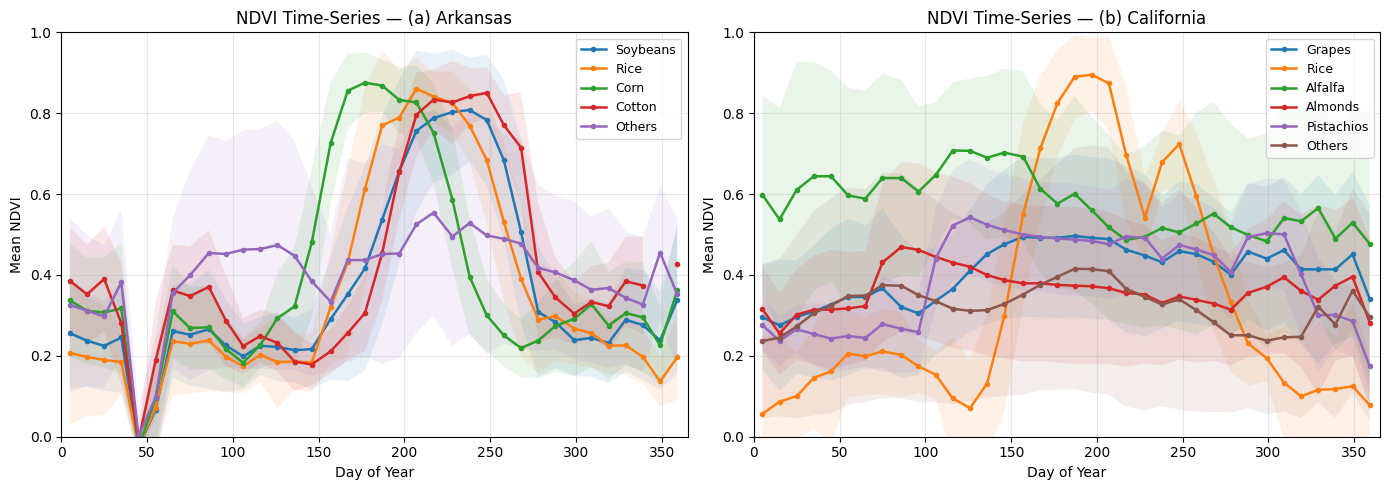

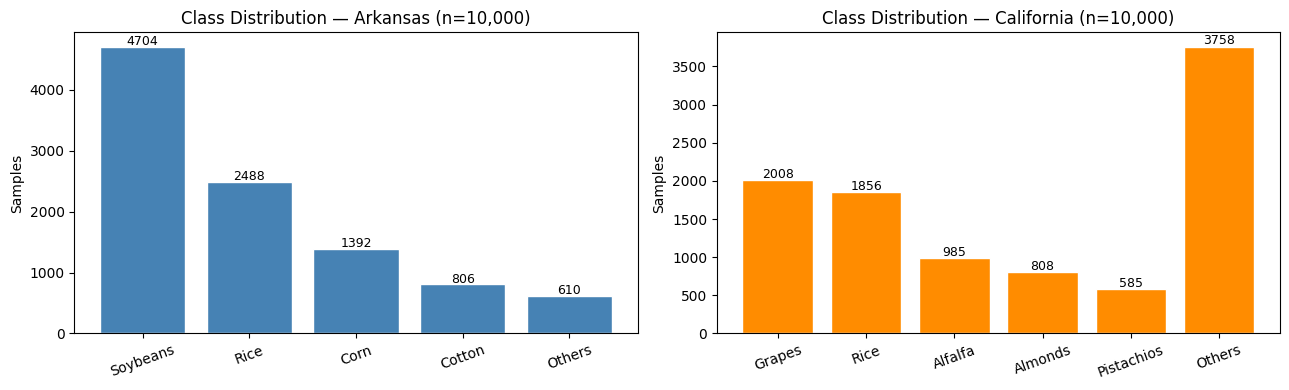

Missing observations — Arkansas: 19.6%  |  California: 13.4%


In [ ]:
DOY = [int((t - 1) * 365 / N_TIMESTEPS) + 5 for t in range(1, N_TIMESTEPS + 1)]

def compute_ndvi_eda(df):
    nir   = df[[f'NIR_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    red   = df[[f'Red_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    valid = df[VALID_COLS].values.astype('float32')
    nir   = np.where(valid == 1, nir, np.nan)
    red   = np.where(valid == 1, red, np.nan)
    return np.clip((nir - red) / (nir + red + 1e-8), -1.0, 1.0)

ndvi_ar = compute_ndvi_eda(df_ar)
ndvi_ca = compute_ndvi_eda(df_ca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ndvi, label_map, title in [
    (axes[0], df_ar, ndvi_ar, AR_LABELS, '(a) Arkansas'),
    (axes[1], df_ca, ndvi_ca, CA_LABELS, '(b) California')
]:
    for code_lbl, name in label_map.items():
        m   = df['label'].values == code_lbl
        mu  = np.nanmean(ndvi[m], axis=0)
        std = np.nanstd(ndvi[m], axis=0)
        ax.plot(DOY, mu, marker='o', markersize=3, linewidth=1.8, label=name)
        ax.fill_between(DOY, mu - std, mu + std, alpha=0.10)
    ax.set_title(f'NDVI Time-Series — {title}')
    ax.set_xlabel('Day of Year'); ax.set_ylabel('Mean NDVI')
    ax.set_xlim(0, 365); ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, label_map, color, title in [
    (axes[0], df_ar, AR_LABELS, 'steelblue',  'Arkansas'),
    (axes[1], df_ca, CA_LABELS, 'darkorange', 'California')
]:
    counts = df['label'].value_counts().sort_index()
    names  = [label_map[i] for i in counts.index]
    ax.bar(names, counts.values, color=color, edgecolor='white')
    ax.set_title(f'Class Distribution — {title} (n=10,000)')
    ax.set_ylabel('Samples'); ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

ar_miss = (1 - df_ar[VALID_COLS].values.mean()) * 100
ca_miss = (1 - df_ca[VALID_COLS].values.mean()) * 100
print(f'Missing observations — Arkansas: {ar_miss:.1f}%  |  California: {ca_miss:.1f}%')


### 2.1 Covariate distributions and associations

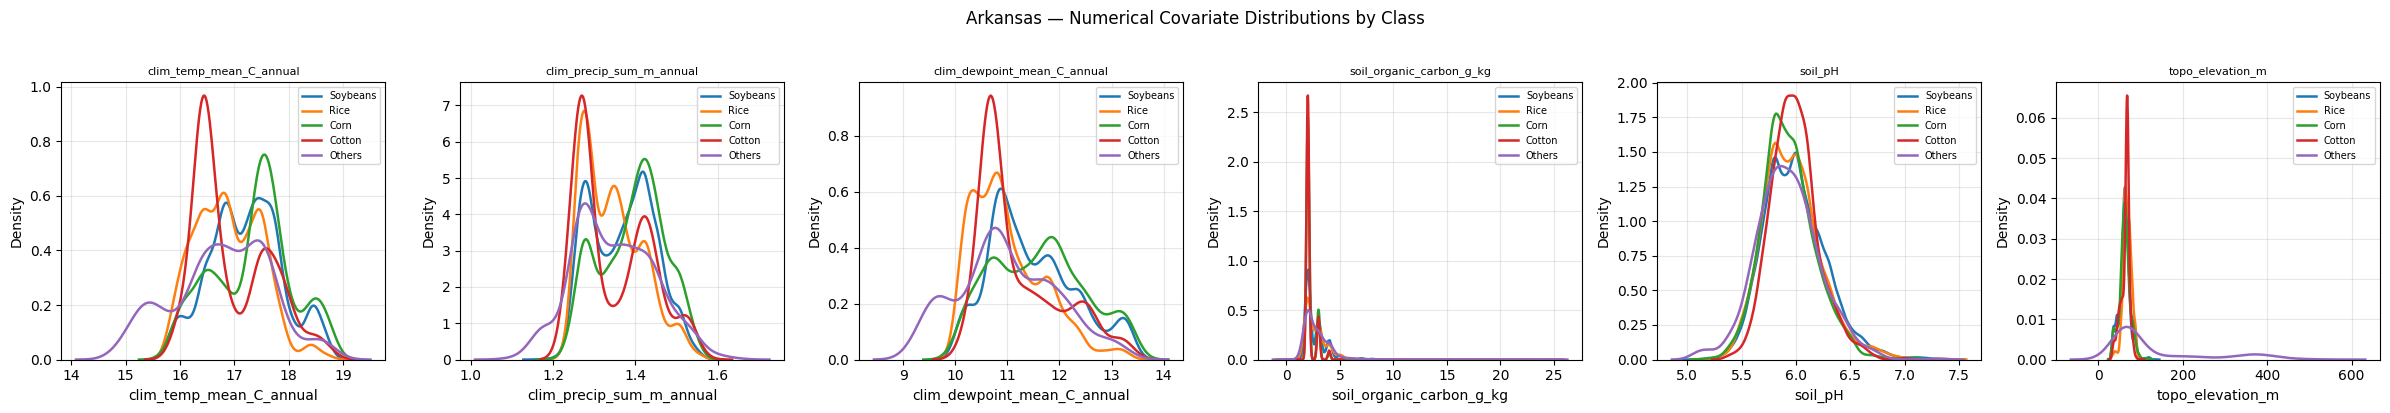

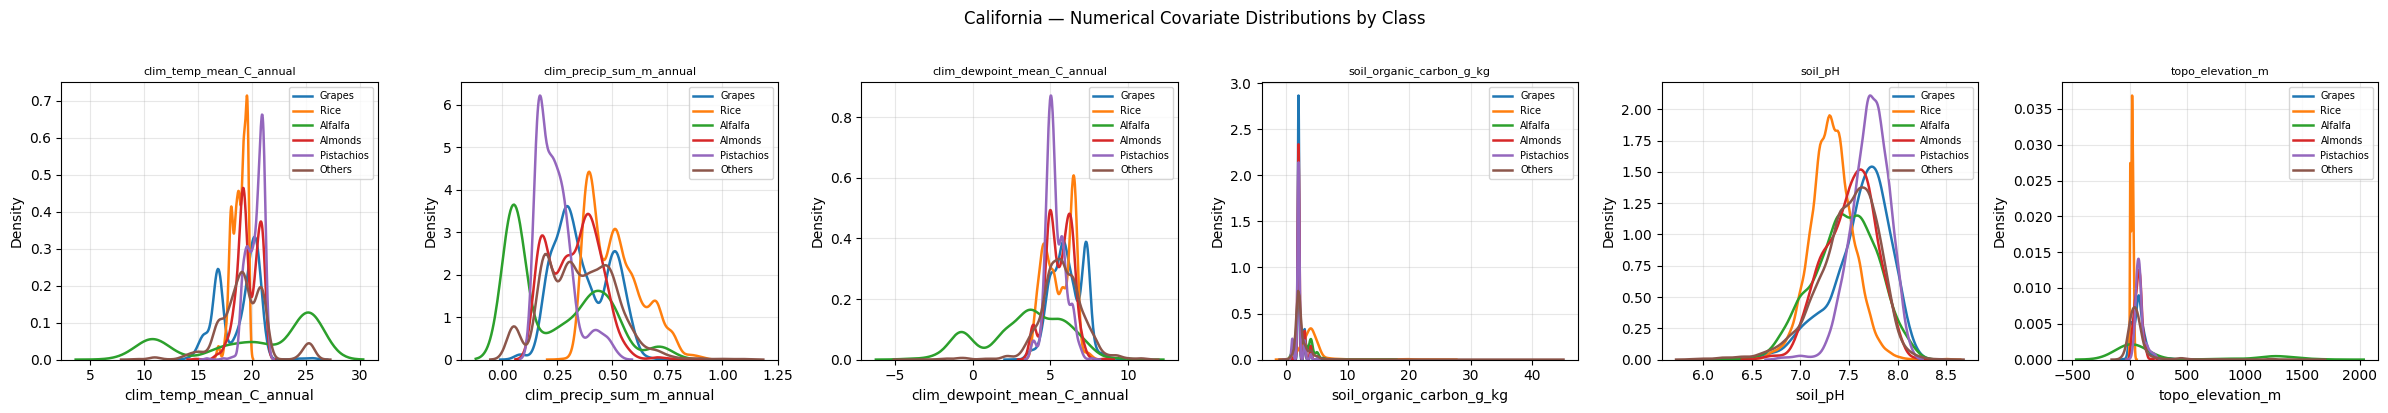

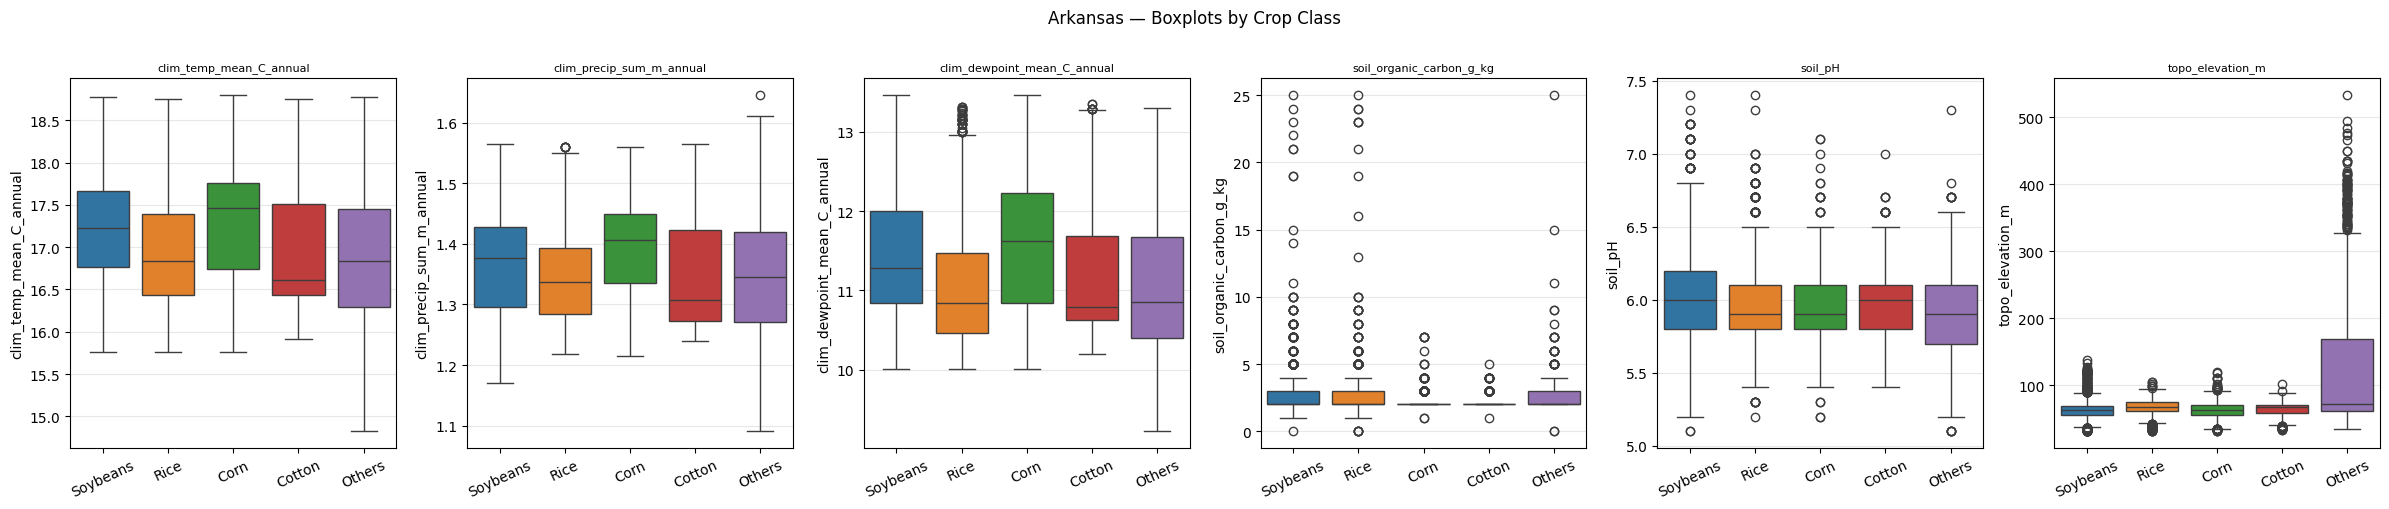

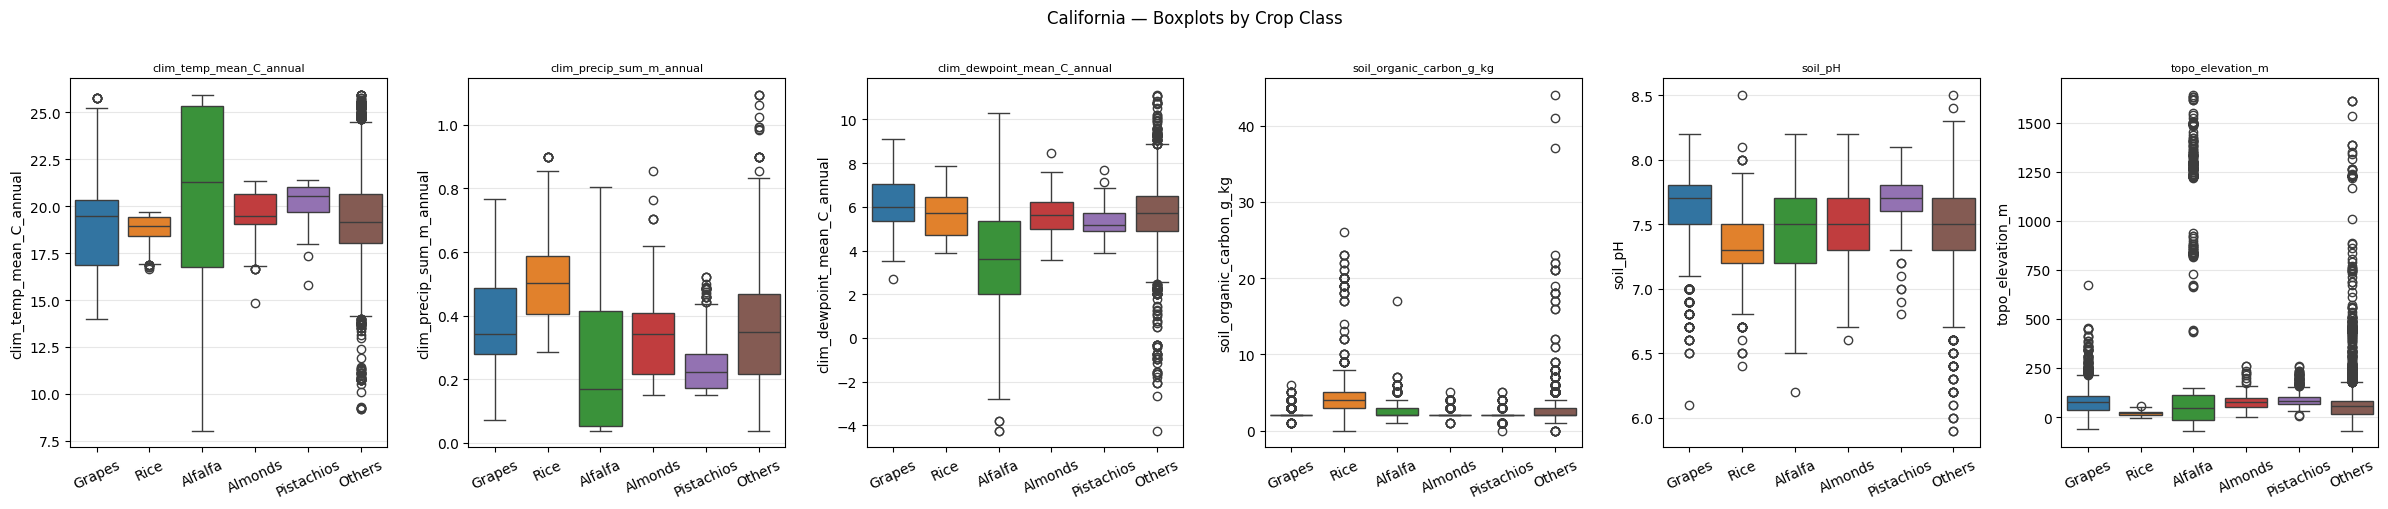

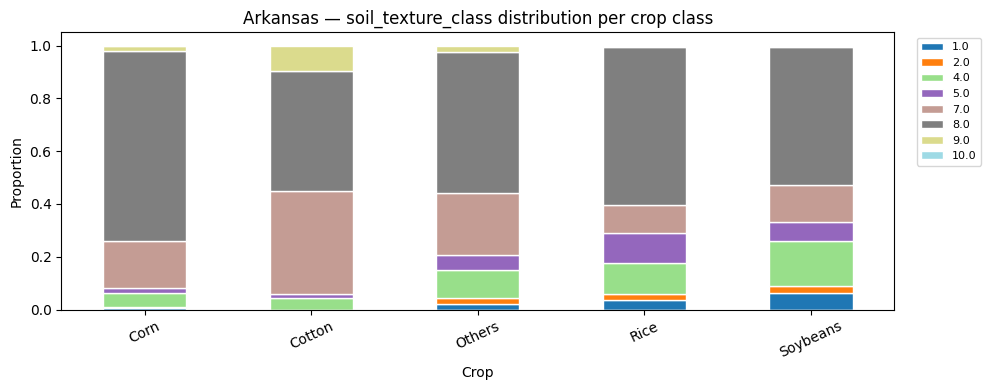

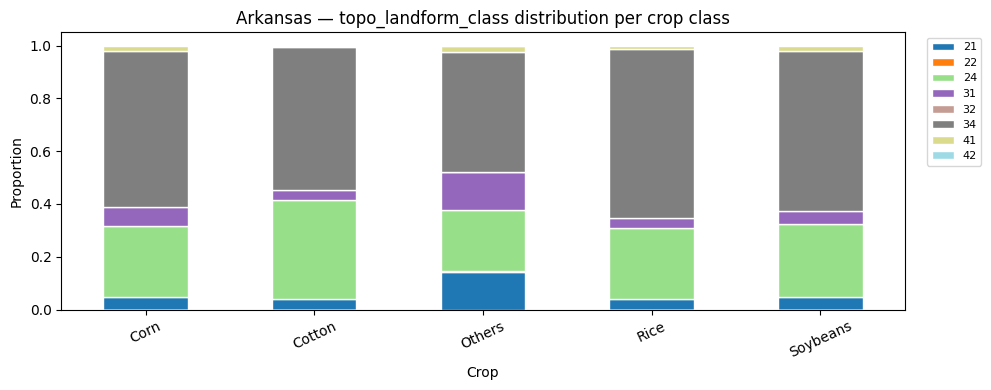

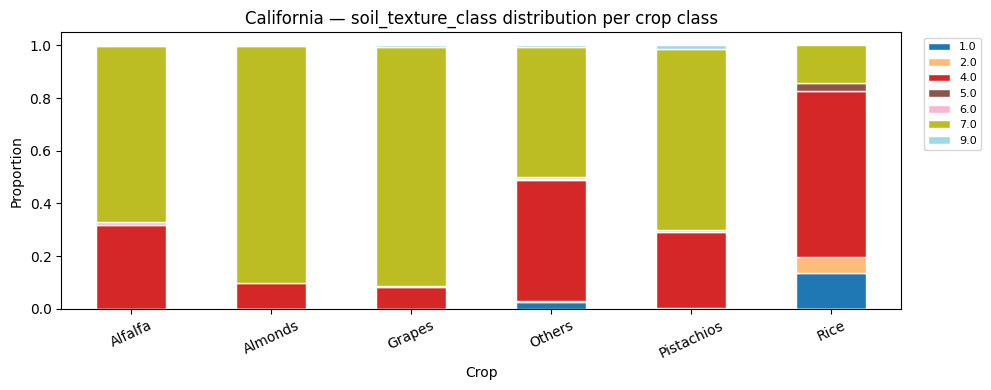

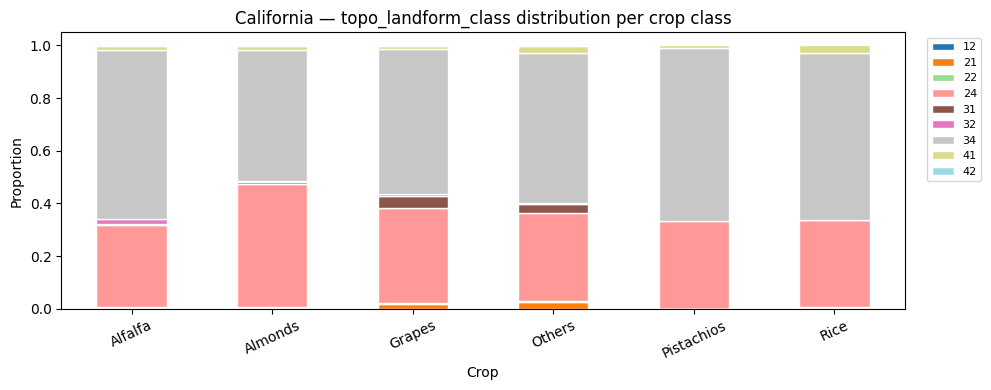

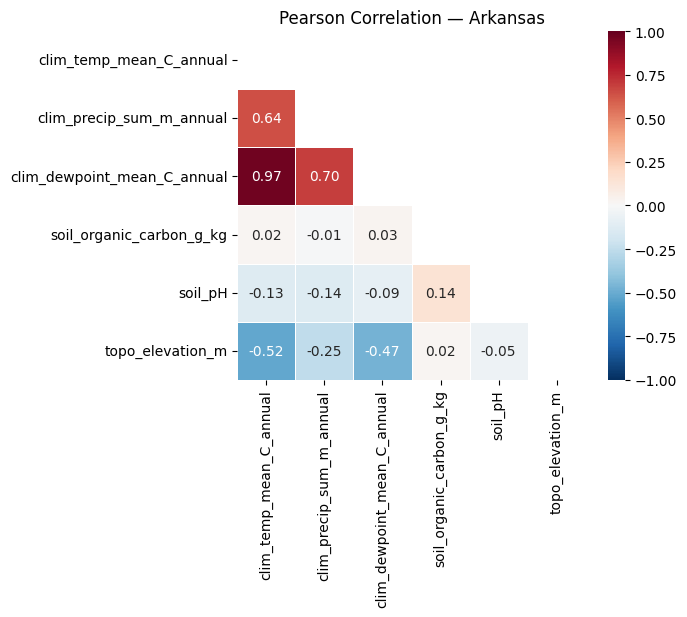

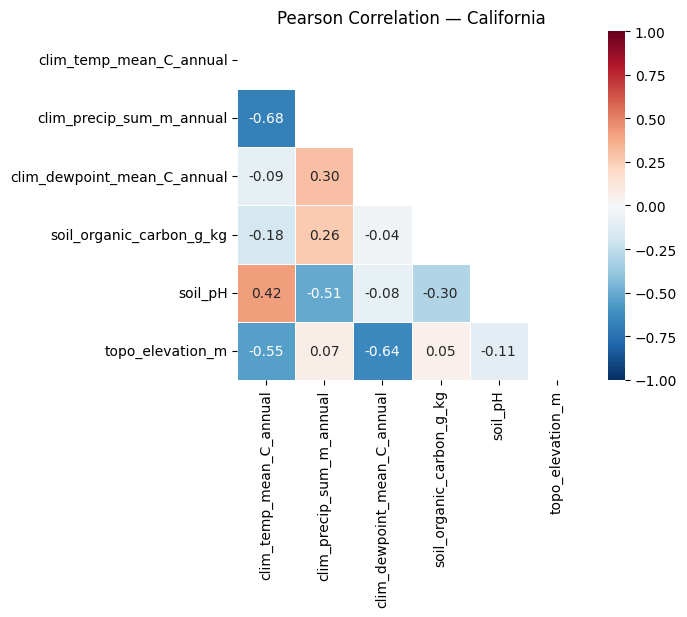


===== Arkansas =====

Numerical covariates (ANOVA F-statistic, p-value):
  clim_temp_mean_C_annual                   F=   180.90  p=6.69e-150  ***
  clim_precip_sum_m_annual                  F=   111.68  p=2.72e-93  ***
  clim_dewpoint_mean_C_annual               F=   209.23  p=1.15e-172  ***
  soil_organic_carbon_g_kg                  F=    80.19  p=4.35e-67  ***
  soil_pH                                   F=    19.53  p=5.08e-16  ***
  topo_elevation_m                          F=   721.90  p=0.00e+00  ***

Categorical covariates (Cramér's V):
  soil_texture_class                        V=0.1841  chi2=1356.09  p=3.55e-268
  topo_landform_class                       V=0.0959  chi2=367.77  p=6.55e-61

===== California =====

Numerical covariates (ANOVA F-statistic, p-value):
  clim_temp_mean_C_annual                   F=    75.65  p=4.53e-78  ***
  clim_precip_sum_m_annual                  F=   637.37  p=0.00e+00  ***
  clim_dewpoint_mean_C_annual               F=   574.45  p=0.00e+00 

In [ ]:
def plot_covar_distributions(df, label_map, covar_cols, title_prefix):
    n = len(covar_cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    palette = sns.color_palette('tab10', len(label_map))
    for ax, col in zip(axes, covar_cols):
        for (code_lbl, name), color in zip(label_map.items(), palette):
            subset = df.loc[df['label'] == code_lbl, col].dropna()
            sns.kdeplot(subset, ax=ax, label=name, color=color, linewidth=1.8)
        ax.set_title(col, fontsize=8); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    fig.suptitle(f'{title_prefix} — Numerical Covariate Distributions by Class', y=1.02)
    plt.tight_layout(); plt.show()

def plot_covar_boxplots(df, label_map, covar_cols, title_prefix):
    df_plot = df.copy()
    df_plot['crop'] = df_plot['label'].map(label_map)
    n = len(covar_cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, covar_cols):
        order = [label_map[k] for k in sorted(label_map)]
        sns.boxplot(data=df_plot, x='crop', y=col, order=order, palette='tab10', ax=ax)
        ax.set_title(col, fontsize=8); ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=25); ax.grid(alpha=0.3, axis='y')
    fig.suptitle(f'{title_prefix} — Boxplots by Crop Class', y=1.01)
    plt.tight_layout(); plt.show()

def plot_cat_distributions(df, label_map, cat_cols, title_prefix):
    df_plot = df.copy(); df_plot['crop'] = df_plot['label'].map(label_map)
    for col in cat_cols:
        cross = pd.crosstab(df_plot['crop'], df_plot[col], normalize='index')
        cross.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab20', edgecolor='white')
        plt.title(f'{title_prefix} — {col} distribution per crop class')
        plt.ylabel('Proportion'); plt.xlabel('Crop')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        plt.xticks(rotation=25); plt.tight_layout(); plt.show()

def plot_correlation_heatmap(df, covar_cols, title):
    corr = df[covar_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5)
    ax.set_title(f'Pearson Correlation — {title}')
    plt.tight_layout(); plt.show()
    return corr

def covariate_class_association(df, label_map, covar_num, covar_cat, title):
    print(f'\n===== {title} =====')
    print('\nNumerical covariates (ANOVA F-statistic, p-value):')
    for col in covar_num:
        groups = [df.loc[df['label'] == c, col].dropna().values for c in sorted(label_map)]
        F, p = f_oneway(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {col:40s}  F={F:9.2f}  p={p:.2e}  {sig}')
    print("\nCategorical covariates (Cramér's V):")
    for col in covar_cat:
        ct = pd.crosstab(df['label'], df[col])
        chi2_val, p_val, dof, _ = chi2_contingency(ct)
        n = ct.values.sum(); k = min(ct.shape) - 1
        v = np.sqrt(chi2_val / (n * k)) if k > 0 else 0
        print(f'  {col:40s}  V={v:.4f}  chi2={chi2_val:.2f}  p={p_val:.2e}')

plot_covar_distributions(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_covar_distributions(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')
plot_covar_boxplots(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_covar_boxplots(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')
plot_cat_distributions(df_ar, AR_LABELS, COVAR_CAT, 'Arkansas')
plot_cat_distributions(df_ca, CA_LABELS, COVAR_CAT, 'California')
corr_ar = plot_correlation_heatmap(df_ar, COVAR_DISPLAY_NUM, 'Arkansas')
corr_ca = plot_correlation_heatmap(df_ca, COVAR_DISPLAY_NUM, 'California')
covariate_class_association(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, COVAR_CAT, 'Arkansas')
covariate_class_association(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, COVAR_CAT, 'California')


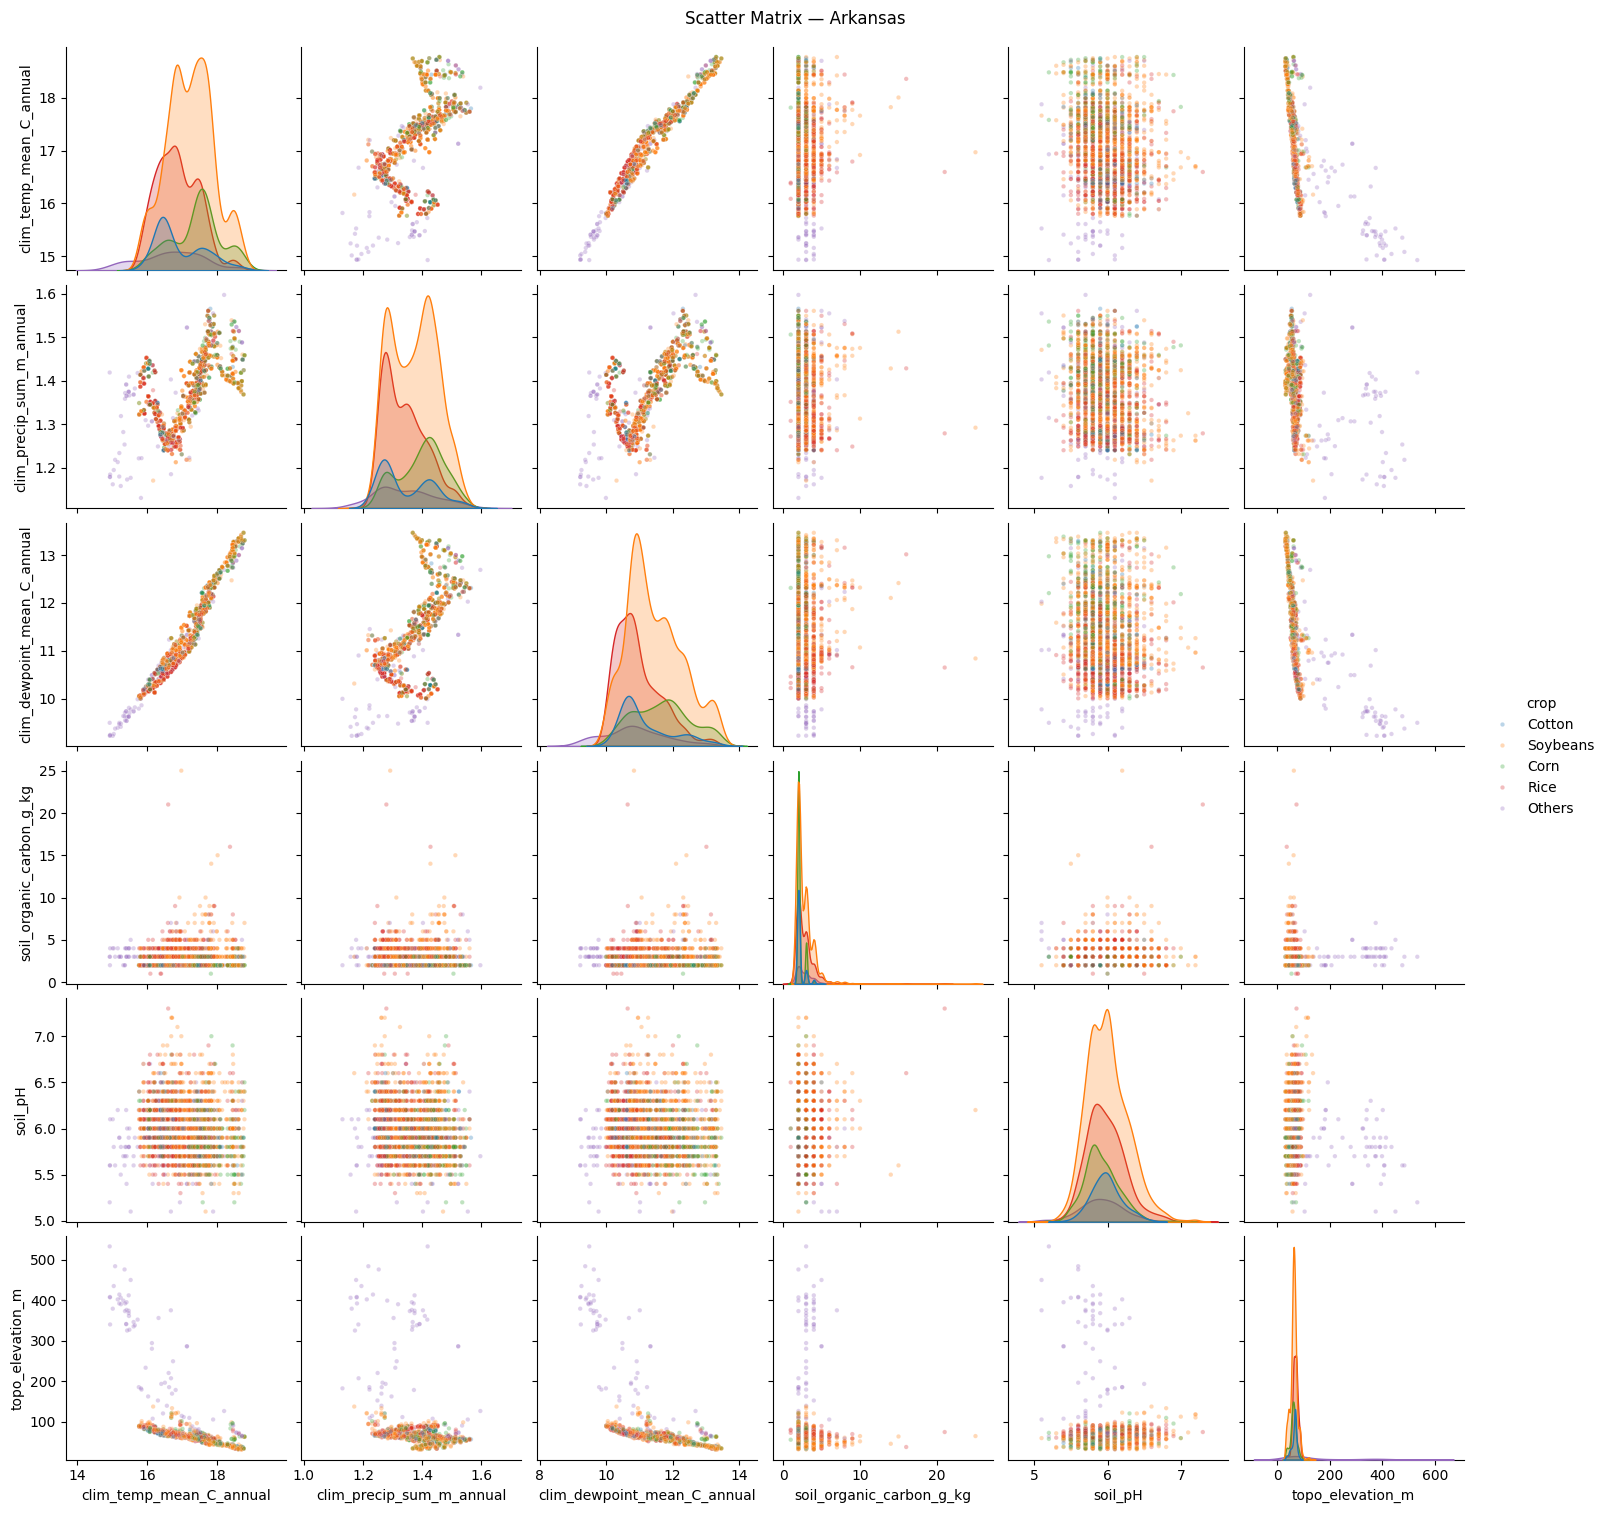

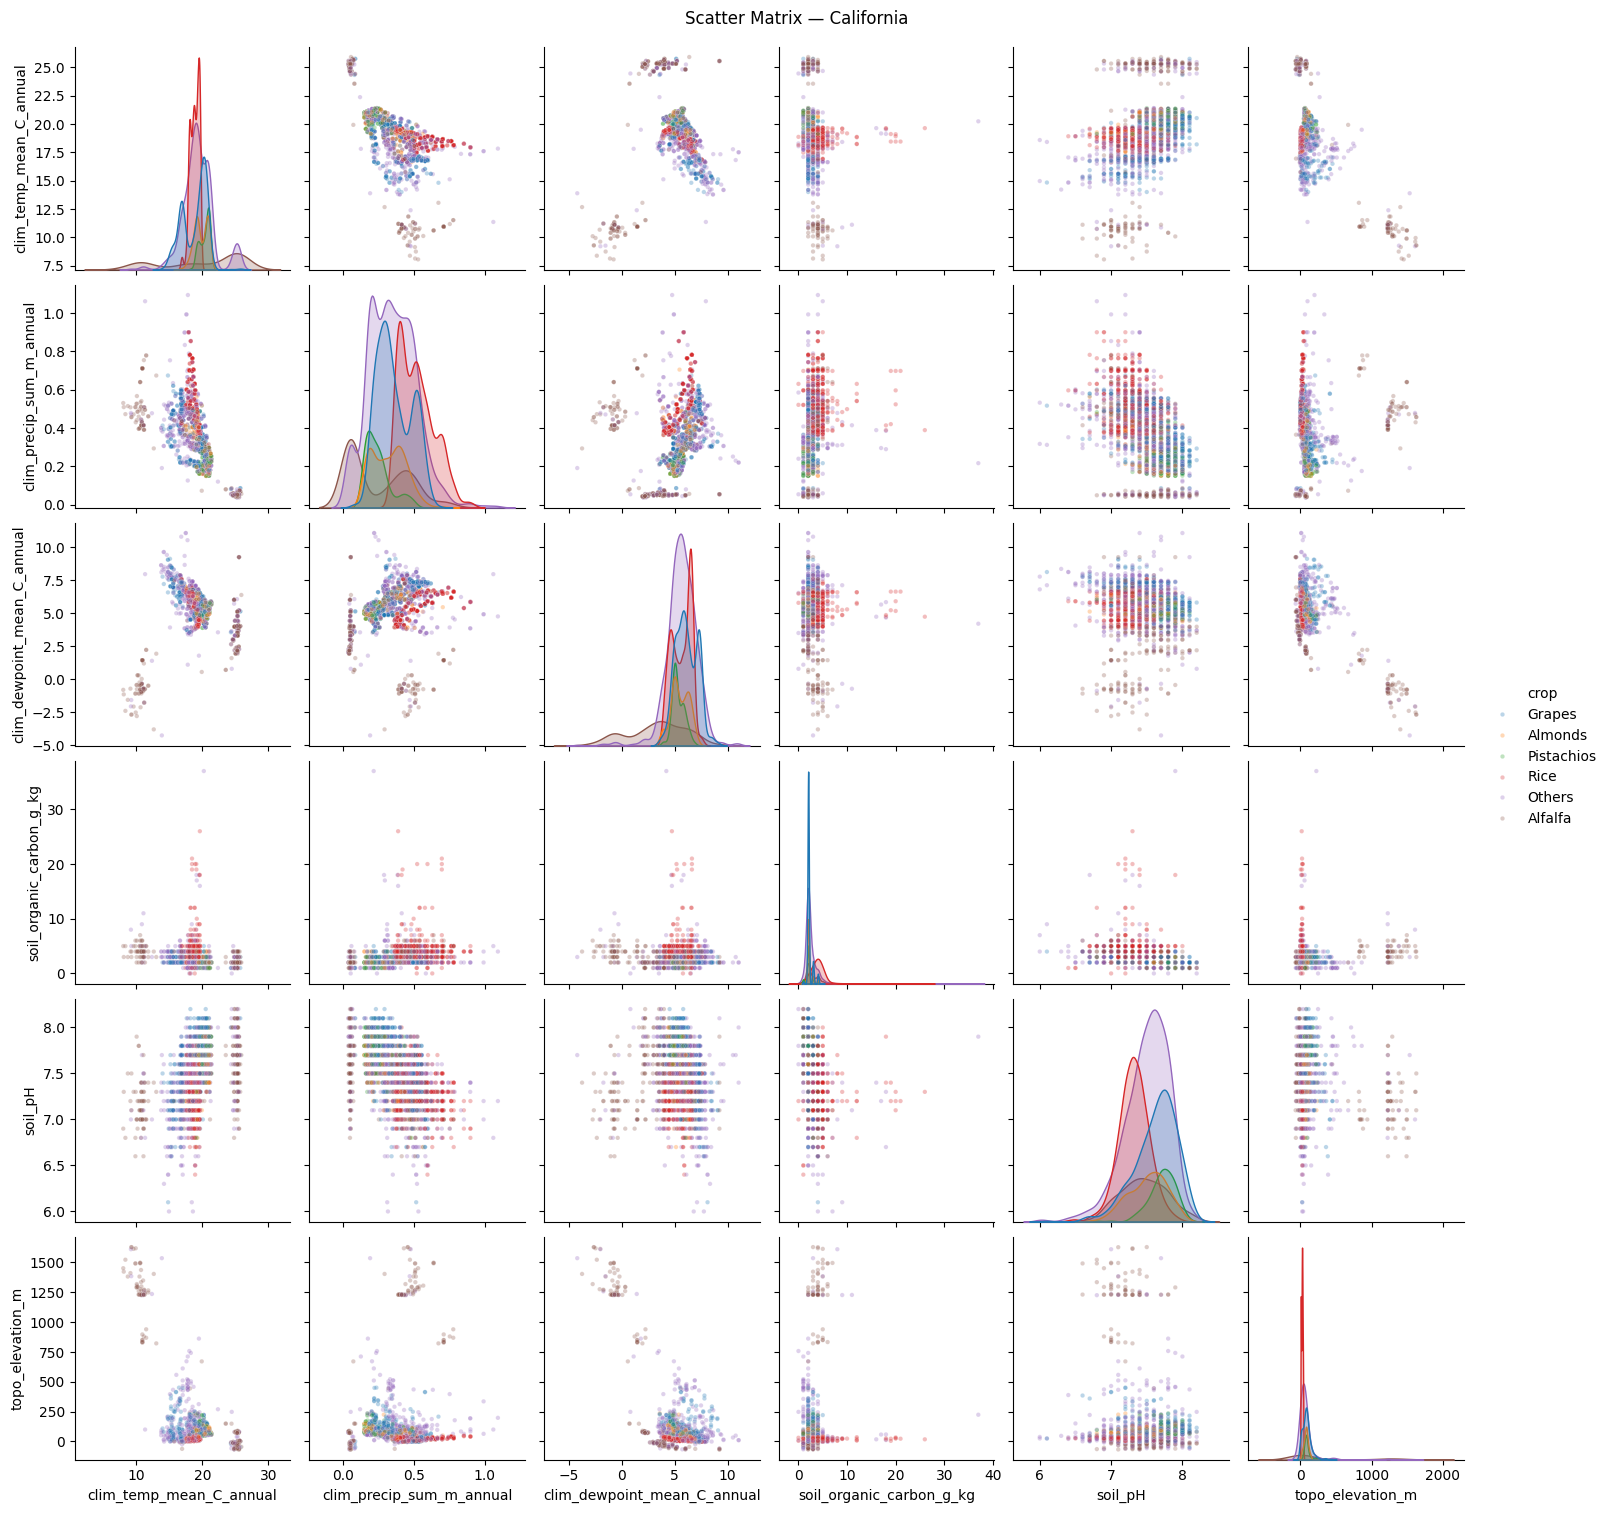

In [ ]:
def plot_scatter_matrix(df, label_map, covar_cols, title, max_samples=3000):
    df_plot = df.sample(min(max_samples, len(df)), random_state=SEED).copy()
    df_plot['crop'] = df_plot['label'].map(label_map)
    g = sns.pairplot(df_plot[covar_cols + ['crop']], hue='crop', diag_kind='kde',
                     plot_kws={'alpha': 0.3, 's': 10}, palette='tab10')
    g.fig.suptitle(f'Scatter Matrix — {title}', y=1.01, fontsize=12)
    plt.show()

plot_scatter_matrix(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_scatter_matrix(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')


## Step 3 — Preprocessing

In [ ]:

def interpolate_cloud_gaps(X, mask, max_gap=2):
    X_out = X.copy()
    N, T, C = X.shape
    m = mask[:, :, 0]
    for n in range(N):
        valid_t = np.where(m[n] == 1)[0]
        if len(valid_t) < 2:
            continue
        t = 0
        while t < T:
            if m[n, t] == 0:
                gap_end = t
                while gap_end < T and m[n, gap_end] == 0:
                    gap_end += 1
                gap_len = gap_end - t
                if gap_len <= max_gap:
                    left  = valid_t[valid_t < t]
                    right = valid_t[valid_t >= gap_end]
                    if len(left) > 0 and len(right) > 0:
                        t0, t1 = left[-1], right[0]
                        for g in range(gap_len):
                            alpha = (t + g - t0) / (t1 - t0)
                            X_out[n, t + g] = (1 - alpha) * X[n, t0] + alpha * X[n, t1]
                t = gap_end
            else:
                t += 1
    return X_out



BAND_IDX = {b: i for i, b in
            enumerate(['Blue','Green','NIR','RE1','RE2','RE3','RE4','Red','SWIR1','SWIR2'])}

def compute_vi(X, mask):
    eps  = 1e-8
    nir  = X[:, :, BAND_IDX['NIR']]
    red  = X[:, :, BAND_IDX['Red']]
    re1  = X[:, :, BAND_IDX['RE1']]
    re2  = X[:, :, BAND_IDX['RE2']]
    re3  = X[:, :, BAND_IDX['RE3']]
    ndvi  = (nir - red)  / (nir + red + eps)
    ireci = (re3 - red)  / (re1 / (re2 + eps) + eps)
    mtci  = (re2 - re1)  / (re1 - red + eps)
    s2rep = 705 + 35 * ((red + re3) / 2 - re1) / (re2 - re1 + eps)
    def norm01(arr, lo, hi): return np.clip((arr - lo) / (hi - lo + eps), 0, 1)
    vi = np.stack([norm01(ndvi, -1, 1), norm01(ireci, 0, 20),
                   norm01(mtci, 0, 10), norm01(s2rep, 690, 740)], axis=-1)
    return (vi * mask).astype('float32')


def build_covariate_encoder(df_train_rows):
    ct = ColumnTransformer([
        ('num', StandardScaler(),       COVAR_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COVAR_CAT),
    ])
    ct.fit(df_train_rows[ALL_COVARS])
    return ct




def _paper_split(y, n_trainval, val_frac=0.2, seed=SEED, min_test_support=0):
    rng = np.random.default_rng(seed)
    tr_idx, va_idx, te_idx = [], [], []
    for cls in np.unique(y):
        idx   = rng.permutation(np.where(y == cls)[0])
        n_cls = len(idx)

        if min_test_support > 0:
            effective_tv = min(n_trainval, max(1, n_cls - min_test_support))
        else:
            effective_tv = n_trainval
        tv   = idx[:effective_tv]
        rest = idx[effective_tv:]
        n_va = max(1, int(len(tv) * val_frac))
        va_idx.extend(tv[:n_va])
        tr_idx.extend(tv[n_va:])
        te_idx.extend(rest)
    return np.array(tr_idx), np.array(va_idx), np.array(te_idx)


def preprocess_part12(df, label_map, state):

    print(f'\n--- {state} (Part 1/2 preprocessing) ---')
    X    = df[SPEC_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, N_BANDS)
    mask = df[VALID_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, 1)
    y    = df['label'].values.astype('int32')

    tr_i, va_i, te_i = _paper_split(y, n_trainval=300)
    print(f'  Train: {len(tr_i)} | Val: {len(va_i)} | Test: {len(te_i)}')

    X_tr_flat  = X[tr_i]
    valid_vals = X_tr_flat[X_tr_flat > 0]
    v_min = float(valid_vals.min())
    v_max = float(X_tr_flat.max())
    X = np.where(X > 0, (X - v_min) / (v_max - v_min + 1e-8), 0.0).astype('float32')
    print(f'  Spectral norm (train-only): v_min={v_min:.4f}  v_max={v_max:.4f}')

    covar_encoder = build_covariate_encoder(df.iloc[tr_i])
    C_all = covar_encoder.transform(df[ALL_COVARS]).astype('float32')
    print(f'  Covariate dim (after encoding): {C_all.shape[1]}')

    class_names = [label_map[i] for i in sorted(label_map)]
    return (
        (X[tr_i], mask[tr_i], C_all[tr_i], y[tr_i]),
        (X[va_i], mask[va_i], C_all[va_i], y[va_i]),
        (X[te_i], mask[te_i], C_all[te_i], y[te_i]),
        class_names, covar_encoder
    )


def preprocess_part3(df, label_map, state):
    print(f'\n--- {state} (Part 3 preprocessing) ---')
    X    = df[SPEC_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, N_BANDS)
    mask = df[VALID_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, 1)
    y    = df['label'].values.astype('int32')


    tr_i, va_i, te_i = _paper_split(y, n_trainval=500, min_test_support=200)
    print(f'  Train: {len(tr_i)} | Val: {len(va_i)} | Test: {len(te_i)}')
    for cls_id, cls_name in label_map.items():
        n_test = int((y[te_i] == cls_id).sum())
        cap_flag = ' (FIX-11 cap active)' if n_test == 200 else ''
        print(f'    {cls_name:<15}: {n_test} test samples{cap_flag}')

    X_tr_flat  = X[tr_i]
    valid_vals = X_tr_flat[X_tr_flat > 0]
    v_min = float(valid_vals.min())
    v_max = float(X_tr_flat.max())
    X = np.where(X > 0, (X - v_min) / (v_max - v_min + 1e-8), 0.0).astype('float32')
    print(f'  Spectral norm (train-only): v_min={v_min:.4f}  v_max={v_max:.4f}')

    X = interpolate_cloud_gaps(X, mask, max_gap=2)
    print('  Cloud-gap interpolation applied (max_gap=2)')

    VI = compute_vi(X, mask)
    X  = np.concatenate([X, VI], axis=-1)
    print(f'  VI features appended: X shape = {X.shape}')

    covar_encoder = build_covariate_encoder(df.iloc[tr_i])
    C_all = covar_encoder.transform(df[ALL_COVARS]).astype('float32')
    print(f'  Covariate dim (after encoding): {C_all.shape[1]}')

    class_names = [label_map[i] for i in sorted(label_map)]
    return (
        (X[tr_i], mask[tr_i], C_all[tr_i], y[tr_i]),
        (X[va_i], mask[va_i], C_all[va_i], y[va_i]),
        (X[te_i], mask[te_i], C_all[te_i], y[te_i]),
        class_names, covar_encoder
    )


print('Preprocessing functions ready.')


Preprocessing functions ready.


## Step 4 — MCTNet Architecture (Part 3 — Improved)

`build_mctnet_p3` / `build_mctnet_with_covariates_p3`: 14-band input, BiGRU(64) + Self-Attention after Stage 3 (FIX-8), per-group gated covariates (FIX-9), asymmetric gate biases (FIX-12).


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2 as _l2


def sinusoidal_pe(T, dm):
    pe  = np.zeros((T, dm), dtype='float32')
    pos = np.arange(T)[:, np.newaxis]
    div = np.exp(np.arange(0, dm, 2) * (-np.log(10000.0) / dm))
    pe[:, 0::2] = np.sin(pos * div)
    if dm % 2 == 0:
        pe[:, 1::2] = np.cos(pos * div)
    else:
        pe[:, 1::2] = np.cos(pos * div[:dm // 2])
    return pe



class ALPELayer(keras.layers.Layer):
    def __init__(self, T, dm, **kwargs):
        super().__init__(**kwargs)
        self.T = T
        self.dm = dm
        pe_matrix = sinusoidal_pe(self.T, self.dm)
        self._pe_init = pe_matrix[np.newaxis]
        self.conv     = layers.Conv1D(dm, kernel_size=3, padding='same')
        self.eca_conv = layers.Conv1D(1,  kernel_size=3, padding='same')

    def build(self, input_shape):
        self._pe_const = tf.constant(self._pe_init, dtype=tf.float32)
        super().build(input_shape)

    def call(self, mask):
        masked_pe = self._pe_const * tf.cast(mask, tf.float32)
        x   = self.conv(masked_pe)
        gap = tf.expand_dims(tf.reduce_mean(x, axis=1), axis=-1)
        gap = tf.squeeze(tf.sigmoid(self.eca_conv(gap)), axis=-1)
        return x * tf.expand_dims(gap, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({'T': self.T, 'dm': self.dm})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)






_COV_L2           = 1e-3
_GATE_BIAS_SINGLE = keras.initializers.Constant(-2.0)
_GATE_BIAS_GROUP  = keras.initializers.Constant(-3.0)





_GROUP_GATE_BIAS = {'Climate': -2.0, 'Soil': -3.0, 'Topography': -3.0}






def cnn_sub_p12(x, filters, kernel_size=3):
    shortcut = x if x.shape[-1] == filters else layers.Conv1D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def transformer_sub_p12(x, n_heads, pos_enc=None):
    if pos_enc is not None:
        x = layers.Add()([x, pos_enc])
    d    = x.shape[-1]
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(1, d // n_heads))(x, x)
    x    = layers.LayerNormalization()(layers.Add()([x, attn]))
    ff   = layers.Dense(d)(layers.Dense(d, activation='relu')(x))
    return layers.LayerNormalization()(layers.Add()([x, ff]))

def mctnet_backbone_p12(inp_feat, inp_mask, n_heads=5):
    alpe_enc = ALPELayer(T=N_TIMESTEPS, dm=N_BANDS, name='alpe')(inp_mask)
    cnn1 = cnn_sub_p12(inp_feat, filters=10)
    tr1  = layers.Conv1D(10, 1, padding='same')(
               transformer_sub_p12(inp_feat, n_heads, pos_enc=alpe_enc))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn1, tr1]))
    cnn2 = cnn_sub_p12(x, filters=20)
    tr2  = layers.Conv1D(20, 1, padding='same')(transformer_sub_p12(x, n_heads))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn2, tr2]))
    cnn3 = cnn_sub_p12(x, filters=40)
    tr3  = layers.Conv1D(40, 1, padding='same')(transformer_sub_p12(x, n_heads))
    return layers.GlobalMaxPooling1D()(layers.Concatenate()([cnn3, tr3]))

def build_mctnet_p12(n_classes, n_heads=5):
    inp_feat = keras.Input(shape=(N_TIMESTEPS, N_BANDS),  name='features')
    inp_mask = keras.Input(shape=(N_TIMESTEPS, 1),        name='mask')
    emb = mctnet_backbone_p12(inp_feat, inp_mask, n_heads)
    out = layers.Dense(n_classes, activation='softmax')(emb)
    return keras.Model([inp_feat, inp_mask], out, name='MCTNet_P12_baseline')



def _covariate_branch(inp_covar, group_sizes, gate_biases=None):
    if group_sizes is None or len(group_sizes) <= 1:
        cov  = layers.Dense(64, activation='relu', kernel_regularizer=_l2(_COV_L2))(inp_covar)
        cov  = layers.Dense(32, activation='relu', kernel_regularizer=_l2(_COV_L2))(cov)

        if gate_biases is not None:
            _gb = (keras.initializers.Constant(gate_biases)
                   if isinstance(gate_biases, (int, float)) else gate_biases)
        else:
            _gb = _GATE_BIAS_SINGLE
        gate = layers.Dense(1, activation='sigmoid', bias_initializer=_gb,
                            name='gate_group_0')(inp_covar)
        return layers.Multiply()([cov, gate])
    else:
        gated_parts = []; offset = 0
        for i, n_g in enumerate(group_sizes):
            g_slice = layers.Lambda(
                lambda x, s=offset, e=offset+n_g: x[:, s:e],
                name=f'slice_group_{i}'
            )(inp_covar)
            hd = max(16, n_g // 4); ed = max(4, n_g // 16)
            g  = layers.Dense(hd, kernel_regularizer=_l2(_COV_L2))(g_slice)
            g  = layers.BatchNormalization()(g)
            g  = layers.Activation('relu')(g)
            g  = layers.Dense(ed, activation='relu', kernel_regularizer=_l2(_COV_L2),
                              name=f'embed_group_{i}')(g)

            if isinstance(gate_biases, list) and i < len(gate_biases):
                _gb_i = gate_biases[i]
            else:
                _gb_i = _GATE_BIAS_GROUP
            gate = layers.Dense(1, activation='sigmoid', bias_initializer=_gb_i,
                                name=f'gate_group_{i}')(g_slice)
            gated_parts.append(layers.Multiply(name=f'gated_group_{i}')([g, gate]))
            offset += n_g
        return layers.Concatenate(name='all_gated_covars')(gated_parts)


def build_mctnet_with_covariates_p12(n_classes, n_covariates, group_sizes=None,
                                      gate_biases=None, n_heads=5):
    inp_feat  = keras.Input(shape=(N_TIMESTEPS, N_BANDS),  name='features')
    inp_mask  = keras.Input(shape=(N_TIMESTEPS, 1),        name='mask')
    inp_covar = keras.Input(shape=(n_covariates,),         name='covariates')
    emb       = mctnet_backbone_p12(inp_feat, inp_mask, n_heads)
    cov_out   = _covariate_branch(inp_covar, group_sizes, gate_biases=gate_biases)
    fused     = layers.Concatenate(name='fused')([emb, cov_out])
    out       = layers.Dense(n_classes, activation='softmax')(fused)
    return keras.Model([inp_feat, inp_mask, inp_covar], out, name='MCTNet_P12_covariates')






def cnn_sub_p3(x, filters, kernel_size=3):
    shortcut = x if x.shape[-1] == filters else layers.Conv1D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def transformer_sub_p3(x, n_heads, pos_enc=None):
    if pos_enc is not None:
        x = layers.Add()([x, pos_enc])
    d    = x.shape[-1]
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(4, d // n_heads))(x, x)
    x    = layers.LayerNormalization()(layers.Add()([x, attn]))
    ff   = layers.Dense(d)(layers.Dense(d, activation='relu')(x))
    return layers.LayerNormalization()(layers.Add()([x, ff]))

def mctnet_backbone_p3(inp_feat, inp_mask, n_heads=5):
    alpe_enc = ALPELayer(T=N_TIMESTEPS, dm=N_INPUT_BANDS, name='alpe')(inp_mask)

    cnn1 = cnn_sub_p3(inp_feat, filters=N_INPUT_BANDS)
    tr1  = layers.Conv1D(N_INPUT_BANDS, 1, padding='same')(
               transformer_sub_p3(inp_feat, n_heads, pos_enc=alpe_enc))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn1, tr1]))

    cnn2 = cnn_sub_p3(x, filters=28)
    tr2  = layers.Conv1D(28, 1, padding='same')(transformer_sub_p3(x, n_heads))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn2, tr2]))

    cnn3 = cnn_sub_p3(x, filters=56)
    tr3  = layers.Conv1D(56, 1, padding='same')(transformer_sub_p3(x, n_heads))
    x    = layers.Concatenate()([cnn3, tr3])

    x = layers.Bidirectional(layers.GRU(64, return_sequences=True),
                              name='bigru_temporal')(x)
    x = layers.Dropout(0.10, name='gru_dropout')(x)
    x = layers.Attention(name='temporal_attention')([x, x])
    return layers.GlobalMaxPooling1D(name='global_pool')(x)

def build_mctnet_p3(n_classes, n_heads=5):
    inp_feat = keras.Input(shape=(N_TIMESTEPS, N_INPUT_BANDS), name='features')
    inp_mask = keras.Input(shape=(N_TIMESTEPS, 1),              name='mask')
    emb = mctnet_backbone_p3(inp_feat, inp_mask, n_heads)
    out = layers.Dense(n_classes, activation='softmax',
                       kernel_regularizer=_l2(1e-4))(emb)
    return keras.Model([inp_feat, inp_mask], out, name='MCTNet_P3_baseline')

def build_mctnet_with_covariates_p3(n_classes, n_covariates, group_sizes=None,
                                     gate_biases=None, n_heads=5):
    inp_feat  = keras.Input(shape=(N_TIMESTEPS, N_INPUT_BANDS), name='features')
    inp_mask  = keras.Input(shape=(N_TIMESTEPS, 1),              name='mask')
    inp_covar = keras.Input(shape=(n_covariates,),               name='covariates')
    emb       = mctnet_backbone_p3(inp_feat, inp_mask, n_heads)
    cov_out   = _covariate_branch(inp_covar, group_sizes, gate_biases=gate_biases)
    fused     = layers.Concatenate(name='fused')([emb, cov_out])
    out       = layers.Dense(n_classes, activation='softmax',
                             kernel_regularizer=_l2(1e-4))(fused)
    return keras.Model([inp_feat, inp_mask, inp_covar], out, name='MCTNet_P3_covariates')



demo12 = build_mctnet_p12(n_classes=5)
demo3  = build_mctnet_p3(n_classes=5)
print(f'Part 1/2 baseline parameters : {demo12.count_params():,}')
print(f'Part 3   baseline parameters : {demo3.count_params():,}')
print('Architecture definitions ready.')


Part 1/2 baseline parameters : 29,489
Part 3   baseline parameters : 124,951
Architecture definitions ready.


## Step 5 — Training Utilities

In [ ]:
def reset_seeds(seed=SEED):
    np.random.seed(seed)
    _random.seed(seed)
    tf.random.set_seed(seed)


def _smooth_sparse_xent(y_true, y_pred, smoothing=0.05):
    n_cls = tf.shape(y_pred)[-1]
    y_oh  = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), n_cls)
    y_s   = y_oh * (1.0 - smoothing) + smoothing / tf.cast(n_cls, tf.float32)
    return tf.reduce_mean(
        -tf.reduce_sum(y_s * tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0)), axis=-1)
    )


def train_model(model, train_data, val_data, epochs=200, batch_size=32):

    if len(train_data) == 4:
        Xtr, mtr, Ctr, ytr = train_data
        Xva, mva, Cva, yva = val_data
        inputs_tr = [Xtr, mtr, Ctr];  inputs_va = [Xva, mva, Cva]
    else:
        Xtr, mtr, ytr = train_data
        Xva, mva, yva = val_data
        inputs_tr = [Xtr, mtr];  inputs_va = [Xva, mva]

    cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
    class_weights = dict(zip(np.unique(ytr), cw))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=_smooth_sparse_xent,
        metrics=['accuracy']
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20,
            min_delta=1e-4,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=8, min_lr=1e-6, verbose=1
        )
    ]
    return model.fit(
        inputs_tr, ytr,
        validation_data=(inputs_va, yva),
        epochs=epochs, batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks, verbose=1
    )


def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'],         label='Train')
    ax[0].plot(history.history['val_loss'],     label='Val')
    ax[0].set_title(f'Loss — {title}'); ax[0].set_xlabel('Epoch')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(history.history['accuracy'],     label='Train')
    ax[1].plot(history.history['val_accuracy'], label='Val')
    ax[1].set_title(f'Accuracy — {title}'); ax[1].set_xlabel('Epoch')
    ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()



_MIN_RELIABLE_SUPPORT = 150

def evaluate_test(model, test_data, class_names, state):
    if len(test_data) == 4:
        Xte, mte, Cte, yte = test_data;  inputs = [Xte, mte, Cte]
    else:
        Xte, mte, yte = test_data;       inputs = [Xte, mte]
    preds = model.predict(inputs, verbose=0).argmax(axis=1)
    oa    = accuracy_score(yte, preds)
    kappa = cohen_kappa_score(yte, preds)
    f1    = f1_score(yte, preds, average='macro')
    print(f'\n--- {state} Test Results ---')
    print(f'OA={oa:.4f}  Kappa={kappa:.4f}  F1-macro={f1:.4f}')
    print(classification_report(yte, preds, target_names=class_names))


    from sklearn.metrics import classification_report as _cr
    import re
    unreliable = []
    for cls_idx, cls_name in enumerate(class_names):
        n = int((yte == cls_idx).sum())
        if n < _MIN_RELIABLE_SUPPORT:
            unreliable.append((cls_name, n))
    if unreliable:
        print(f'  ⚠ RELIABILITY WARNING — classes with < {_MIN_RELIABLE_SUPPORT} test samples ')
        print(f'    have statistically unstable F1/precision estimates:')
        for name, n in unreliable:
            print(f'    • {name}: {n} test samples — treat per-class F1 with caution')
        print()

    cm = confusion_matrix(yte, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {state}')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    axes[0].tick_params(axis='x', rotation=30)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'Normalised Confusion Matrix — {state}')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()
    return oa, kappa, f1


def print_gate_diagnostics(model, test_data, group_names=None):
    if len(test_data) != 4: return
    Xte, mte, Cte, yte = test_data;  inputs = [Xte, mte, Cte]
    gate_layers = [l for l in model.layers if l.name.startswith('gate_group_')]
    if not gate_layers: return
    print('\n  — Learned Gate Values (mean ± std over test set) —')
    for i, gl in enumerate(sorted(gate_layers, key=lambda l: l.name)):
        gate_model = keras.Model(model.inputs, gl.output)
        gate_vals  = gate_model.predict(inputs, verbose=0).flatten()
        label = group_names[i] if group_names and i < len(group_names) else gl.name
        bar   = '█' * int(gate_vals.mean() * 20)
        print(f'  {label:15s}: {gate_vals.mean():.3f} ± {gate_vals.std():.3f}  |{bar}')
    print()


print('Training utilities ready.')
print(f'  label_smoothing=0.05, EarlyStopping patience=20, min_delta=1e-4')
print(f'  Reliability warning threshold: {_MIN_RELIABLE_SUPPORT} test samples per class')


Training utilities ready.
  label_smoothing=0.05, EarlyStopping patience=20, min_delta=1e-4
  Reliability warning threshold: 150 test samples per class


In [ ]:
def get_covar_indices(encoder, covar_subset):
    num_features  = encoder.named_transformers_['num'].feature_names_in_.tolist()
    cat_features  = encoder.named_transformers_['cat'].feature_names_in_.tolist()
    n_cat_encoded = encoder.named_transformers_['cat'].categories_
    indices = []
    for i, feat in enumerate(num_features):
        if feat in covar_subset:
            indices.append(i)
    col_ptr = len(num_features)
    for feat, cats in zip(cat_features, n_cat_encoded):
        for j in range(len(cats)):
            if feat in covar_subset:
                indices.append(col_ptr + j)
        col_ptr += len(cats)
    return sorted(indices)


def get_group_sizes(encoder, covar_subset):
    if not covar_subset: return None, []
    GROUPS_ORDERED = [('Climate', CLIM_COLS), ('Soil', SOIL_COLS), ('Topography', TOPO_COLS)]
    num_features = encoder.named_transformers_['num'].feature_names_in_.tolist()
    cat_features = encoder.named_transformers_['cat'].feature_names_in_.tolist()
    cat_sizes    = [len(c) for c in encoder.named_transformers_['cat'].categories_]
    group_sizes = []; group_labels = []
    for grp_name, grp_cols in GROUPS_ORDERED:
        subset_in_group = [c for c in grp_cols if c in covar_subset]
        if not subset_in_group: continue
        size = 0
        for col in subset_in_group:
            if col in num_features:  size += 1
            elif col in cat_features: size += cat_sizes[cat_features.index(col)]
        group_sizes.append(size); group_labels.append(grp_name)
    if len(group_sizes) <= 1: return None, group_labels
    return group_sizes, group_labels


def make_ablation_split(full_split, col_indices):
    X, mask, C_all, y = full_split
    C_sub = C_all[:, col_indices] if col_indices else None
    return X, mask, C_sub, y


ABLATION_CONFIGS = {
    'S2 only'        : [],
    'S2 + Climate'   : CLIM_COLS,
    'S2 + Soil'      : SOIL_COLS,
    'S2 + Topography': TOPO_COLS,
    'S2 + All'       : ALL_COVARS,
}

print('Ablation configurations:')
for name, cols in ABLATION_CONFIGS.items():
    print(f'  {name:20s}: {len(cols) if cols else 0} covariate columns')


Ablation configurations:
  S2 only             : 0 covariate columns
  S2 + Climate        : 108 covariate columns
  S2 + Soil           : 3 covariate columns
  S2 + Topography     : 2 covariate columns
  S2 + All            : 113 covariate columns


In [ ]:
def run_ablation(state, label_map, class_names,
                 full_train, full_val, full_test,
                 covar_encoder, configs, build_baseline_fn, build_cov_fn,
                 epochs=200, batch_size=32,
                 save_models=True, part_tag='part3_improved'):

    n_classes = len(label_map)
    records = []; all_histories = {}

    for cfg_name, covar_cols in configs.items():
        print(f'\n{"="*60}')
        print(f'State: {state}  |  Config: {cfg_name}')
        n_cols = len(covar_cols) if covar_cols else 0
        print(f'Covariates: {n_cols}  {covar_cols[:3] if covar_cols else "none"}'
              f'{" ..." if n_cols > 3 else ""}')
        print('='*60)

        reset_seeds(); tf.keras.backend.clear_session()

        if covar_cols:
            idx   = get_covar_indices(covar_encoder, covar_cols)
            n_cov = len(idx)
            tr    = make_ablation_split(full_train, idx)
            va    = make_ablation_split(full_val,   idx)
            te    = make_ablation_split(full_test,  idx)
            g_sizes, g_labels = get_group_sizes(covar_encoder, covar_cols)

            if g_sizes is not None:
                print(f'  Per-group gating: {list(zip(g_labels, g_sizes))}')
                assert sum(g_sizes) == n_cov
            else:
                print(f'  Single-gate mode ({g_labels})')



            if g_sizes is not None:
                gate_biases = [
                    keras.initializers.Constant(_GROUP_GATE_BIAS.get(lbl, -3.0))
                    for lbl in g_labels
                ]
            elif g_labels and g_labels[0] in ('Topography', 'Soil'):

                gate_biases = keras.initializers.Constant(-3.0)
            else:
                gate_biases = None

            model = build_cov_fn(n_classes, n_cov, group_sizes=g_sizes,
                                  gate_biases=gate_biases)
        else:
            tr    = (full_train[0], full_train[1], full_train[3])
            va    = (full_val[0],   full_val[1],   full_val[3])
            te    = (full_test[0],  full_test[1],  full_test[3])
            model = build_baseline_fn(n_classes)
            g_labels = None

        print(f'Parameters: {model.count_params():,}')
        history = train_model(model, tr, va, epochs=epochs, batch_size=batch_size)
        all_histories[cfg_name] = history
        plot_history(history, f'{state} — {cfg_name}')
        oa, kappa, f1 = evaluate_test(model, te, class_names, f'{state} — {cfg_name}')
        if covar_cols:
            print_gate_diagnostics(model, te, group_names=g_labels)

        if save_models:
            safe_cfg  = cfg_name.replace(' ', '_').replace('+', 'plus')
            safe_state = state.lower()
            model_path = os.path.join(FOLDER, f'mctnet_{part_tag}_{safe_state}_{safe_cfg}.keras')
            model.save(model_path)
            print(f'  Model saved → {model_path}')

        records.append({'Config': cfg_name, 'OA': round(oa,4),
                        'Kappa': round(kappa,4), 'F1-macro': round(f1,4),
                        'Params': model.count_params()})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_histories)))
    for (cfg_name, hist), color in zip(all_histories.items(), colors):
        axes[0].plot(hist.history['val_loss'],     label=cfg_name, color=color, linewidth=1.6)
        axes[1].plot(hist.history['val_accuracy'], label=cfg_name, color=color, linewidth=1.6)
    for ax, ylabel, title in zip(axes, ['Val Loss','Val Accuracy'],
        [f'{state} — Val Loss (all configs)', f'{state} — Val Accuracy (all configs)']):
        ax.set_title(title, fontsize=11); ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return pd.DataFrame(records)


print('Ablation runner ready.')
print('  Per-config model saving enabled (save_models=True by default)')
print('  FIX-12: Asymmetric gate biases (Climate=-2.0, Soil/Topo=-3.0) propagated to build_cov_fn')


Ablation runner ready.
  Per-config model saving enabled (save_models=True by default)
  FIX-12: Asymmetric gate biases (Climate=-2.0, Soil/Topo=-3.0) propagated to build_cov_fn


In [ ]:
def plot_ablation_summary(ablation_ar, ablation_ca, metric='OA', title_suffix=''):
    configs = ablation_ar['Config'].tolist()
    x       = np.arange(len(configs)); width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - width/2, ablation_ar[metric], width,
                   label='Arkansas',   color='steelblue',  edgecolor='white')
    bars2 = ax.bar(x + width/2, ablation_ca[metric], width,
                   label='California', color='darkorange', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(configs, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'Ablation Study — {metric} by Configuration {title_suffix}')
    ax.legend()
    ax.set_ylim(max(0, min(ablation_ar[metric].min(), ablation_ca[metric].min()) - 0.05), 1.0)
    ax.grid(alpha=0.3, axis='y')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()


# Part 3 — Improved Model (BiGRU + Per-Group Gated Covariates)

In [ ]:

ar_train3, ar_val3, ar_test3, ar_classes3, ar_enc3 = preprocess_part3(df_ar, AR_LABELS, 'Arkansas')
ca_train3, ca_val3, ca_test3, ca_classes3, ca_enc3 = preprocess_part3(df_ca, CA_LABELS, 'California')

N_COVAR_AR3 = ar_train3[2].shape[1]
N_COVAR_CA3 = ca_train3[2].shape[1]
print(f'\nArkansas covariate dim  (Part 3): {N_COVAR_AR3}')
print(f'California covariate dim (Part 3): {N_COVAR_CA3}')



--- Arkansas (Part 3 preprocessing) ---
  Train: 1928 | Val: 482 | Test: 7590
    Soybeans       : 4204 test samples
    Rice           : 1988 test samples
    Corn           : 892 test samples
    Cotton         : 306 test samples
    Others         : 200 test samples (FIX-11 cap active)
  Spectral norm (train-only): v_min=0.0005  v_max=1.2424
  Cloud-gap interpolation applied (max_gap=2)
  VI features appended: X shape = (10000, 36, 14)
  Covariate dim (after encoding): 126

--- California (Part 3 preprocessing) ---
  Train: 2308 | Val: 577 | Test: 7115
    Grapes         : 1508 test samples
    Rice           : 1356 test samples
    Alfalfa        : 485 test samples
    Almonds        : 308 test samples
    Pistachios     : 200 test samples (FIX-11 cap active)
    Others         : 3258 test samples
  Spectral norm (train-only): v_min=0.0000  v_max=1.5130
  Cloud-gap interpolation applied (max_gap=2)
  VI features appended: X shape = (10000, 36, 14)
  Covariate dim (after encoding):

### Part 3 — Ablation (S2-only baseline + 4 covariate configurations)


### Part 3 — Arkansas Ablation


State: Arkansas  |  Config: S2 only
Covariates: 0  none
Parameters: 124,951
Epoch 1/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.7215 - loss: 0.8986 - val_accuracy: 0.5021 - val_loss: 1.4713 - learning_rate: 0.0010
Epoch 2/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9284 - loss: 0.4456 - val_accuracy: 0.5415 - val_loss: 1.4476 - learning_rate: 0.0010
Epoch 3/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9507 - loss: 0.3730 - val_accuracy: 0.5083 - val_loss: 1.2471 - learning_rate: 0.0010
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9647 - loss: 0.3383 - val_accuracy: 0.6598 - val_loss: 0.9713 - learning_rate: 0.0010
Epoch 5/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9710 - loss: 0.3213 - val_accuracy: 0.8071 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 6/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9793 - loss: 0.3049 - val_accuracy: 0.9025 - val_loss: 0.4666 - learning_rate: 0.0010
Epoch 7/20

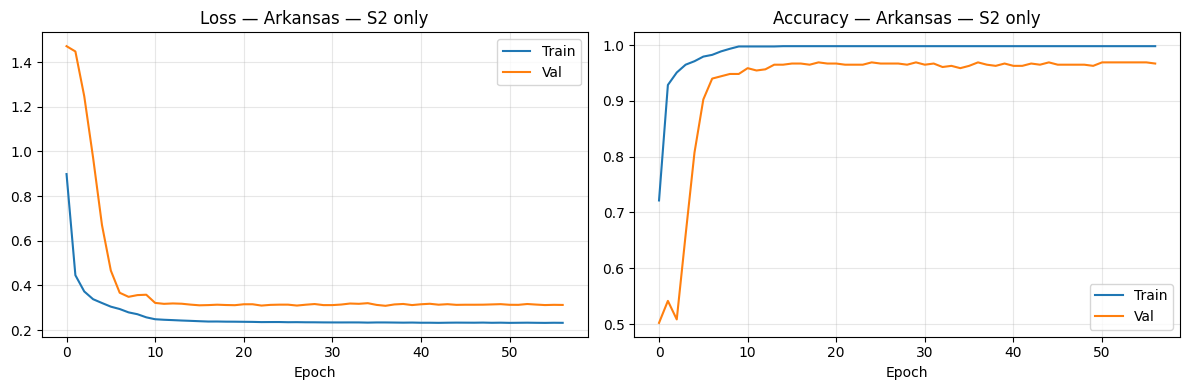


--- Arkansas — S2 only Test Results ---
OA=0.9651  Kappa=0.9439  F1-macro=0.9067
              precision    recall  f1-score   support

    Soybeans       1.00      0.95      0.97      4204
        Rice       1.00      0.99      0.99      1988
        Corn       0.98      0.98      0.98       892
      Cotton       0.87      0.98      0.92       306
      Others       0.51      0.95      0.67       200

    accuracy                           0.97      7590
   macro avg       0.87      0.97      0.91      7590
weighted avg       0.98      0.97      0.97      7590



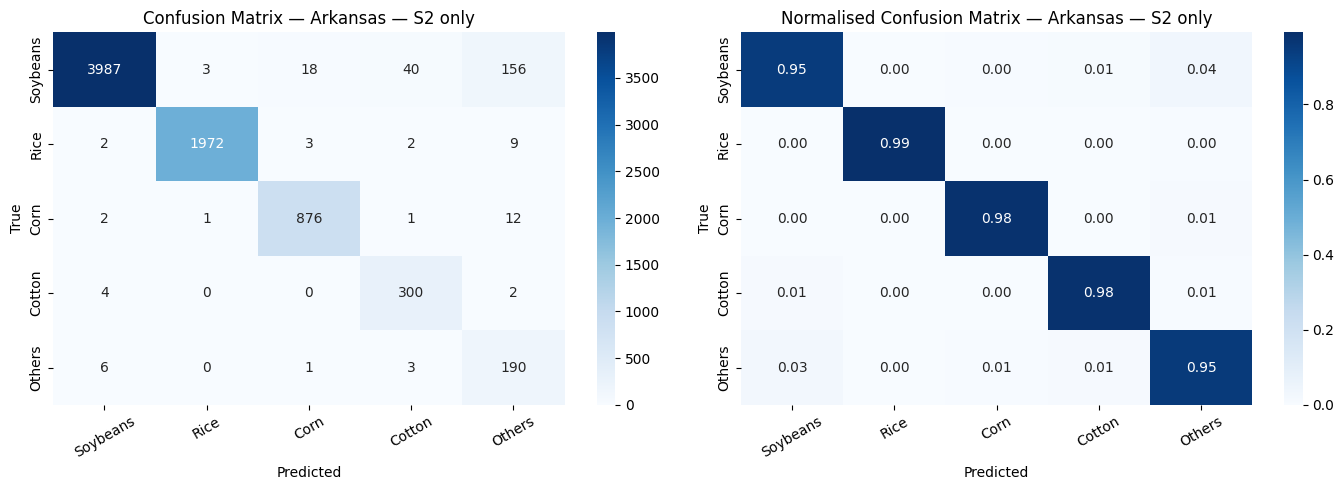

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_arkansas_S2_only.keras

State: Arkansas  |  Config: S2 + Climate
Covariates: 108  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] ...
  Single-gate mode (['Climate'])
Parameters: 134,276
Epoch 1/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.7376 - loss: 0.9798 - val_accuracy: 0.3299 - val_loss: 1.9986 - learning_rate: 0.0010
Epoch 2/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9253 - loss: 0.5225 - val_accuracy: 0.3714 - val_loss: 1.6164 - learning_rate: 0.0010
Epoch 3/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9445 - loss: 0.4455 - val_accuracy: 0.4917 - val_loss: 1.4191 - learning_rate: 0.0010
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9627 - loss: 0.3996 - val_accuracy: 0.6494 - val_loss: 1.1394 - learning_rate: 0.0010
Epoch 5/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9699 - loss: 0.3639 - val_accuracy: 

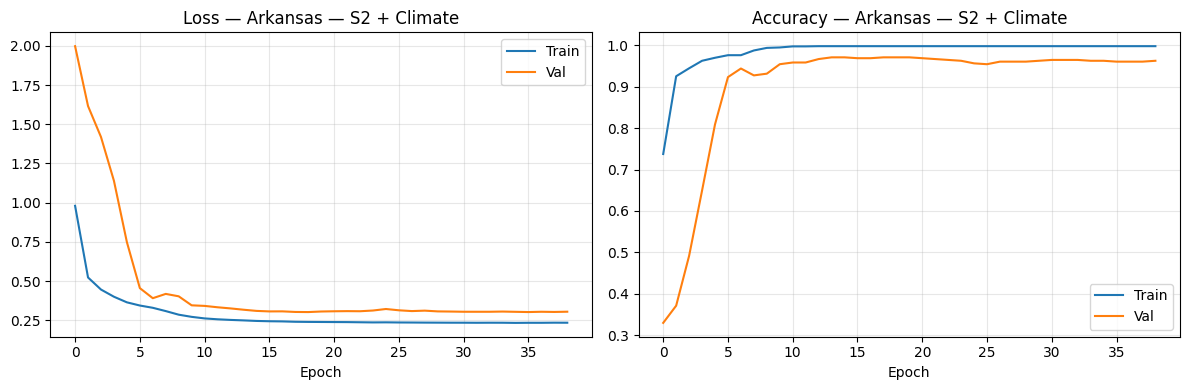


--- Arkansas — S2 + Climate Test Results ---
OA=0.9585  Kappa=0.9338  F1-macro=0.8953
              precision    recall  f1-score   support

    Soybeans       1.00      0.94      0.97      4204
        Rice       1.00      0.99      0.99      1988
        Corn       0.97      0.98      0.98       892
      Cotton       0.82      0.98      0.89       306
      Others       0.48      0.97      0.65       200

    accuracy                           0.96      7590
   macro avg       0.85      0.97      0.90      7590
weighted avg       0.97      0.96      0.96      7590



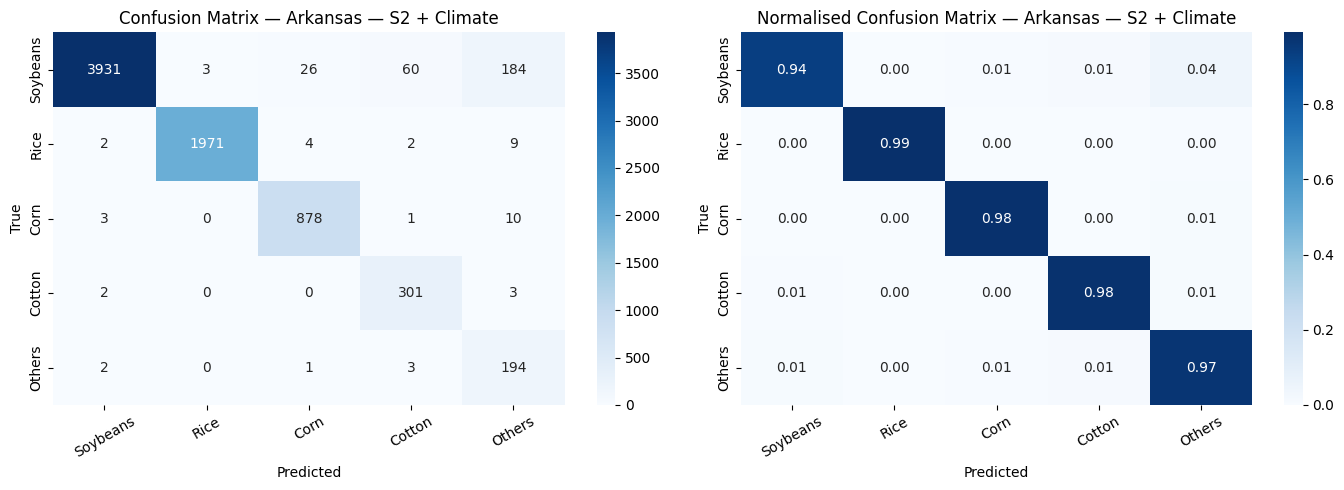


  — Learned Gate Values (mean ± std over test set) —
  Climate        : 0.317 ± 0.357  |██████

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_arkansas_S2_plus_Climate.keras

State: Arkansas  |  Config: S2 + Soil
Covariates: 3  ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
  Single-gate mode (['Soil'])
Parameters: 127,841
Epoch 1/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.7407 - loss: 0.9276 - val_accuracy: 0.2801 - val_loss: 2.0348 - learning_rate: 0.0010
Epoch 2/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9248 - loss: 0.4684 - val_accuracy: 0.3838 - val_loss: 1.6618 - learning_rate: 0.0010
Epoch 3/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9466 - loss: 0.3971 - val_accuracy: 0.5083 - val_loss: 1.3015 - learning_rate: 0.0010
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9564 - loss: 0.3603 - val_accuracy: 0.6826 - val_loss: 0.9860 - learning_rate: 0.0010
Epoch 5/200
61/61 ━━

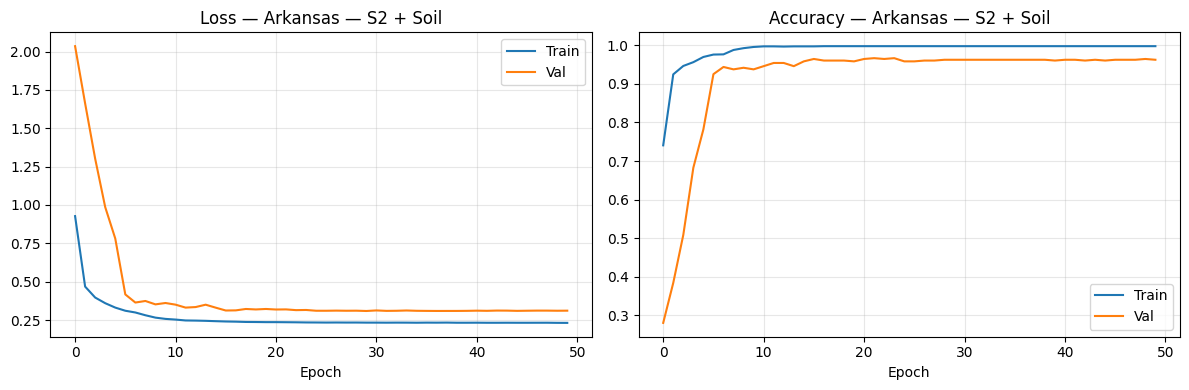


--- Arkansas — S2 + Soil Test Results ---
OA=0.9647  Kappa=0.9434  F1-macro=0.9088
              precision    recall  f1-score   support

    Soybeans       1.00      0.95      0.97      4204
        Rice       1.00      0.99      0.99      1988
        Corn       0.96      0.99      0.97       892
      Cotton       0.89      0.98      0.93       306
      Others       0.52      0.95      0.67       200

    accuracy                           0.96      7590
   macro avg       0.87      0.97      0.91      7590
weighted avg       0.98      0.96      0.97      7590



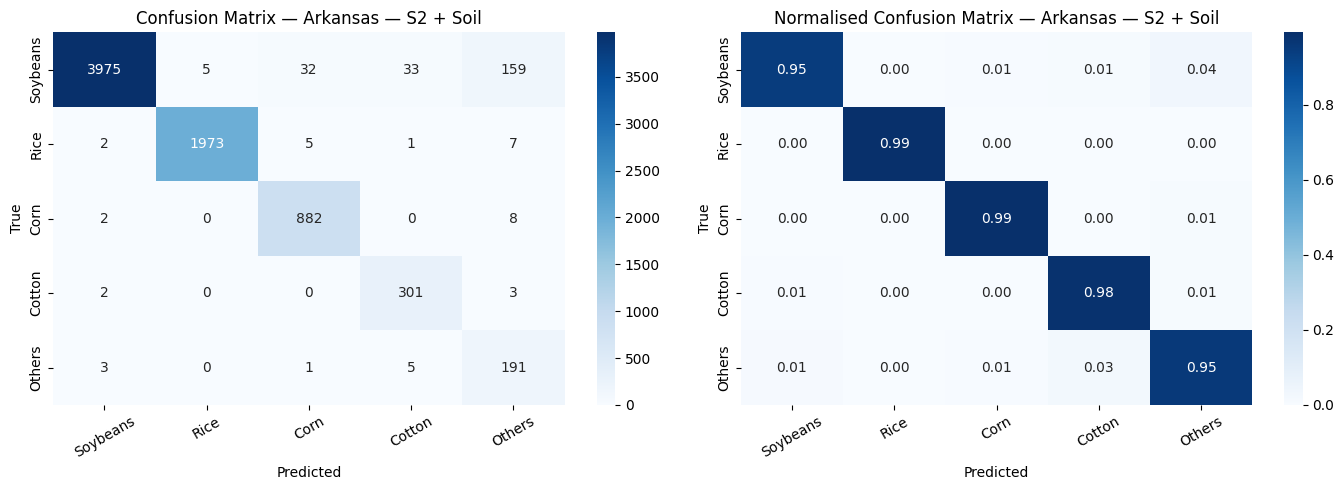


  — Learned Gate Values (mean ± std over test set) —
  Soil           : 0.084 ± 0.137  |█

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_arkansas_S2_plus_Soil.keras

State: Arkansas  |  Config: S2 + Topography
Covariates: 2  ['topo_elevation_m', 'topo_landform_class']
  Single-gate mode (['Topography'])
Parameters: 127,841
Epoch 1/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.7412 - loss: 0.9215 - val_accuracy: 0.2801 - val_loss: 2.0215 - learning_rate: 0.0010
Epoch 2/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9258 - loss: 0.4670 - val_accuracy: 0.4149 - val_loss: 1.4752 - learning_rate: 0.0010
Epoch 3/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9450 - loss: 0.3965 - val_accuracy: 0.5249 - val_loss: 1.2753 - learning_rate: 0.0010
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9575 - loss: 0.3593 - val_accuracy: 0.6680 - val_loss: 1.0657 - learning_rate: 0.0010
Epoch 5/200
61/61 ━━━━━━━━━━━━━━━━

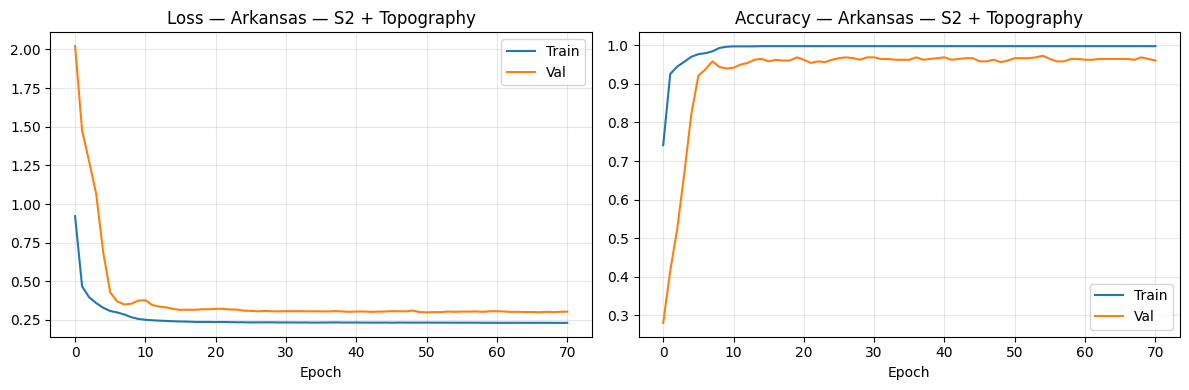


--- Arkansas — S2 + Topography Test Results ---
OA=0.9617  Kappa=0.9387  F1-macro=0.9024
              precision    recall  f1-score   support

    Soybeans       1.00      0.94      0.97      4204
        Rice       1.00      0.99      0.99      1988
        Corn       0.96      0.99      0.97       892
      Cotton       0.86      0.98      0.92       306
      Others       0.50      0.95      0.66       200

    accuracy                           0.96      7590
   macro avg       0.86      0.97      0.90      7590
weighted avg       0.97      0.96      0.97      7590



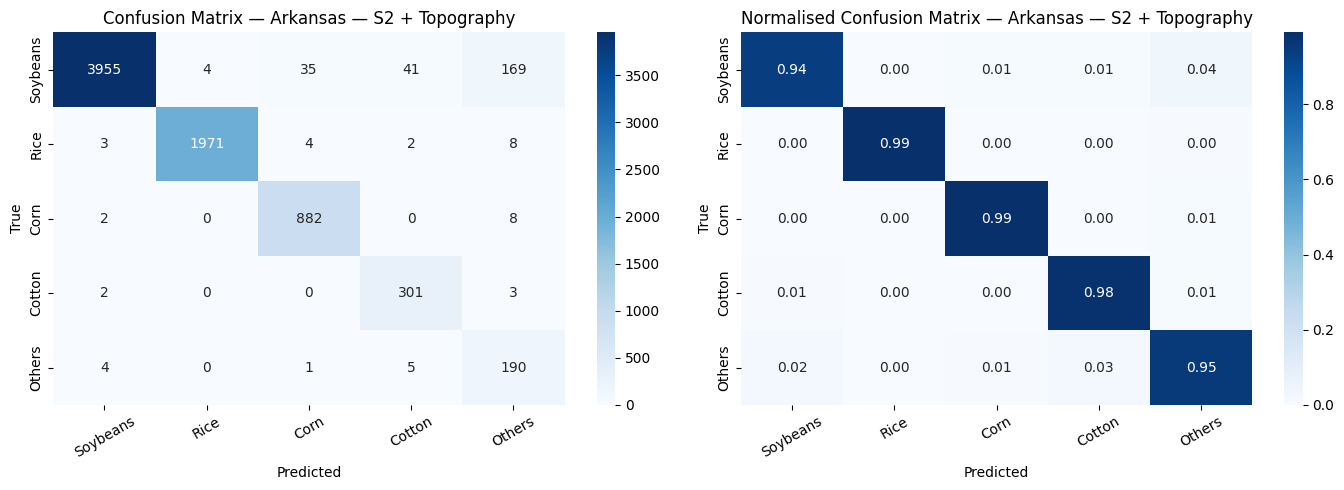


  — Learned Gate Values (mean ± std over test set) —
  Topography     : 0.051 ± 0.073  |█

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_arkansas_S2_plus_Topography.keras

State: Arkansas  |  Config: S2 + All
Covariates: 113  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] ...
  Per-group gating: [('Climate', 108), ('Soil', 9), ('Topography', 9)]
Parameters: 128,953
Epoch 1/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.7147 - loss: 0.9887 - val_accuracy: 0.3216 - val_loss: 2.0761 - learning_rate: 0.0010
Epoch 2/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9289 - loss: 0.5020 - val_accuracy: 0.3444 - val_loss: 2.1588 - learning_rate: 0.0010
Epoch 3/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9538 - loss: 0.4138 - val_accuracy: 0.4959 - val_loss: 1.2728 - learning_rate: 0.0010
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9663 - loss: 0.3674 - val_accuracy: 0.7282 - val_lo

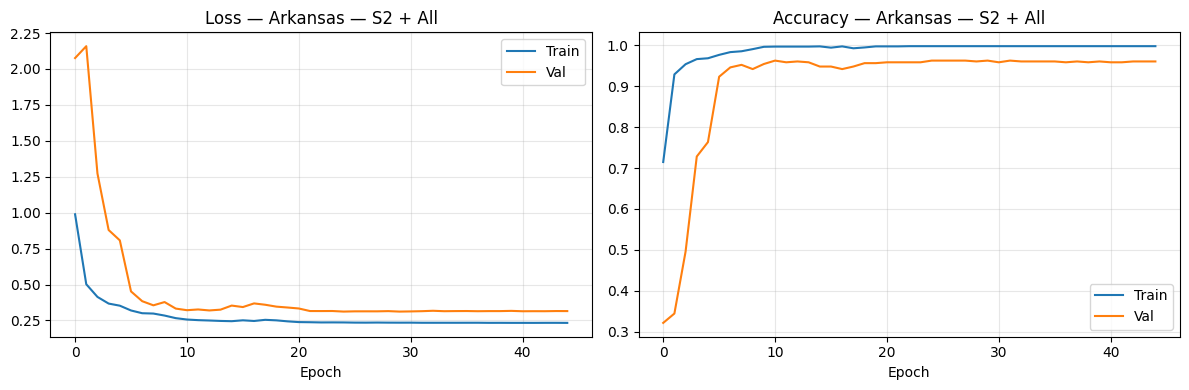


--- Arkansas — S2 + All Test Results ---
OA=0.9660  Kappa=0.9453  F1-macro=0.9098
              precision    recall  f1-score   support

    Soybeans       0.99      0.95      0.97      4204
        Rice       1.00      0.99      0.99      1988
        Corn       0.98      0.98      0.98       892
      Cotton       0.88      0.98      0.93       306
      Others       0.52      0.94      0.67       200

    accuracy                           0.97      7590
   macro avg       0.87      0.97      0.91      7590
weighted avg       0.98      0.97      0.97      7590



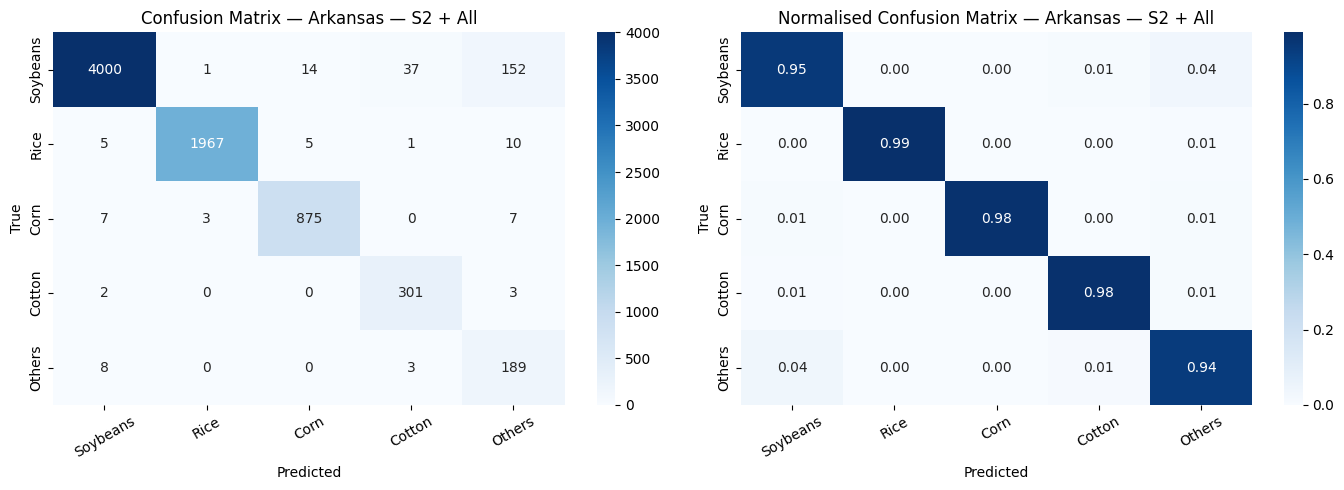


  — Learned Gate Values (mean ± std over test set) —
  Climate        : 0.315 ± 0.377  |██████
  Soil           : 0.106 ± 0.079  |██
  Topography     : 0.035 ± 0.015  |

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_arkansas_S2_plus_All.keras


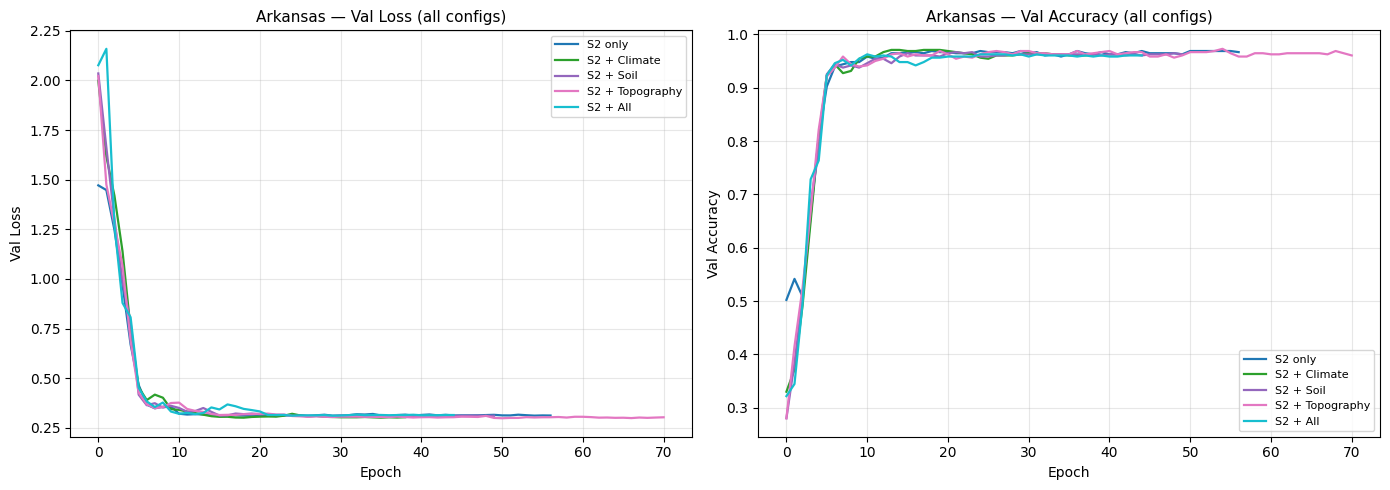


===== Arkansas Ablation (Part 3) =====
         Config     OA  Kappa  F1-macro  Params
        S2 only 0.9651 0.9439    0.9067  124951
   S2 + Climate 0.9585 0.9338    0.8953  134276
      S2 + Soil 0.9647 0.9434    0.9088  127841
S2 + Topography 0.9617 0.9387    0.9024  127841
       S2 + All 0.9660 0.9453    0.9098  128953


In [ ]:
ablation_ar_p3 = run_ablation(
    state='Arkansas', label_map=AR_LABELS, class_names=ar_classes3,
    full_train=ar_train3, full_val=ar_val3, full_test=ar_test3,
    covar_encoder=ar_enc3, configs=ABLATION_CONFIGS,
    build_baseline_fn=build_mctnet_p3,
    build_cov_fn=build_mctnet_with_covariates_p3,
    part_tag='part3_improved',
)
print('\n===== Arkansas Ablation (Part 3) =====')
print(ablation_ar_p3.to_string(index=False))


### Part 3 — California Ablation


State: California  |  Config: S2 only
Covariates: 0  none
Parameters: 125,080
Epoch 1/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6304 - loss: 1.0787 - val_accuracy: 0.1941 - val_loss: 2.1036 - learning_rate: 0.0010
Epoch 2/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7912 - loss: 0.7665 - val_accuracy: 0.4610 - val_loss: 1.3499 - learning_rate: 0.0010
Epoch 3/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8332 - loss: 0.6690 - val_accuracy: 0.6170 - val_loss: 1.1733 - learning_rate: 0.0010
Epoch 4/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8536 - loss: 0.6077 - val_accuracy: 0.6586 - val_loss: 1.0393 - learning_rate: 0.0010
Epoch 5/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8696 - loss: 0.5671 - val_accuracy: 0.7383 - val_loss: 0.8616 - learning_rate: 0.0010
Epoch 6/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8878 - loss: 0.5300 - val_accuracy: 0.7574 - val_loss: 0.8442 - learning_rate: 0.0010
Epoch 7/

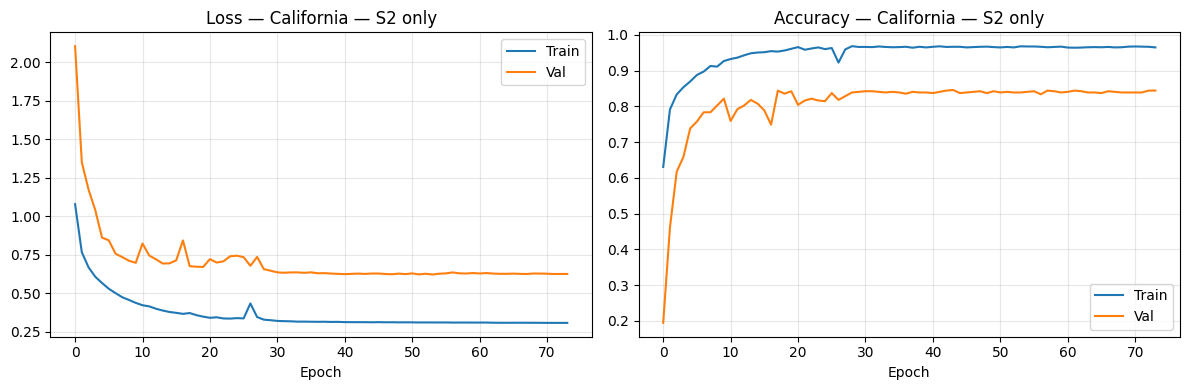


--- California — S2 only Test Results ---
OA=0.8454  Kappa=0.7873  F1-macro=0.8017
              precision    recall  f1-score   support

      Grapes       0.82      0.80      0.81      1508
        Rice       0.99      0.99      0.99      1356
     Alfalfa       0.82      0.94      0.88       485
     Almonds       0.35      0.75      0.48       308
  Pistachios       0.74      0.86      0.80       200
      Others       0.92      0.80      0.85      3258

    accuracy                           0.85      7115
   macro avg       0.77      0.86      0.80      7115
weighted avg       0.87      0.85      0.85      7115



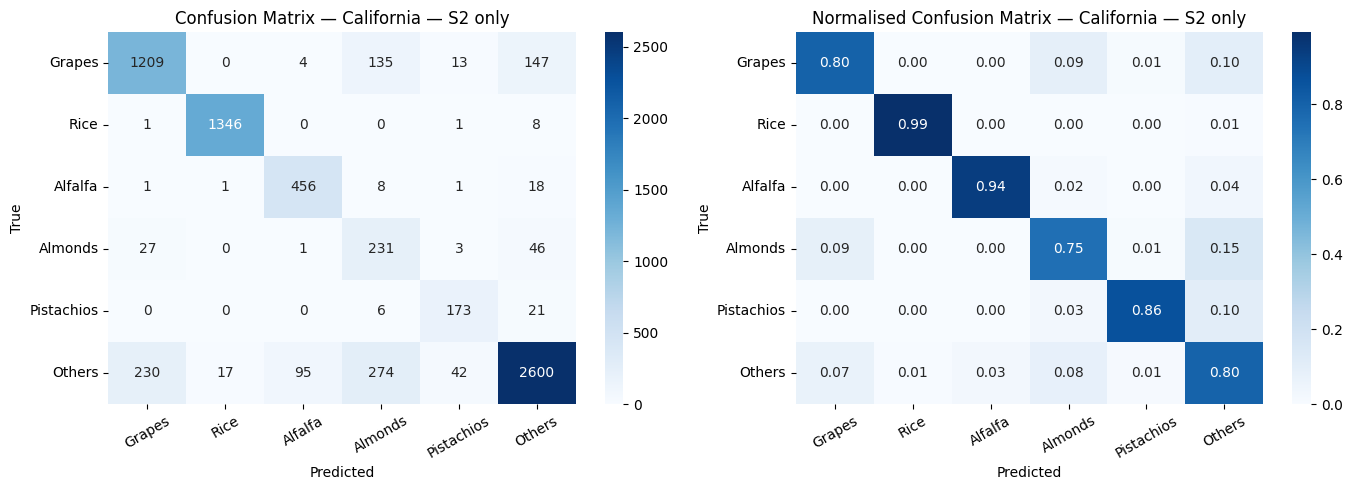

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_california_S2_only.keras

State: California  |  Config: S2 + Climate
Covariates: 108  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] ...
  Single-gate mode (['Climate'])
Parameters: 134,437
Epoch 1/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.6529 - loss: 1.1742 - val_accuracy: 0.3293 - val_loss: 1.7893 - learning_rate: 0.0010
Epoch 2/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8228 - loss: 0.7995 - val_accuracy: 0.5026 - val_loss: 1.3777 - learning_rate: 0.0010
Epoch 3/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8540 - loss: 0.6870 - val_accuracy: 0.6586 - val_loss: 1.1422 - learning_rate: 0.0010
Epoch 4/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8679 - loss: 0.6201 - val_accuracy: 0.7002 - val_loss: 1.0517 - learning_rate: 0.0010
Epoch 5/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8843 - loss: 0.5775 - val_accura

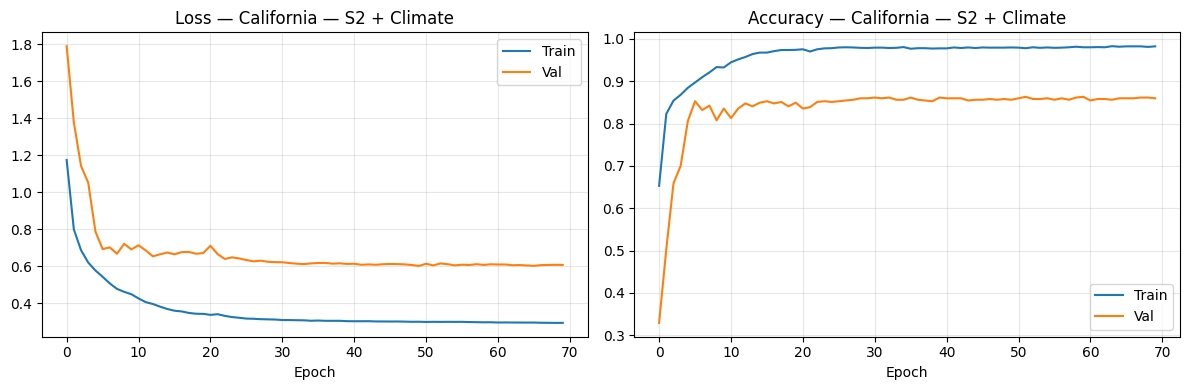


--- California — S2 + Climate Test Results ---
OA=0.8468  Kappa=0.7909  F1-macro=0.7950
              precision    recall  f1-score   support

      Grapes       0.83      0.81      0.82      1508
        Rice       0.99      0.99      0.99      1356
     Alfalfa       0.88      0.94      0.91       485
     Almonds       0.38      0.83      0.53       308
  Pistachios       0.53      0.94      0.68       200
      Others       0.93      0.79      0.85      3258

    accuracy                           0.85      7115
   macro avg       0.76      0.88      0.80      7115
weighted avg       0.88      0.85      0.86      7115



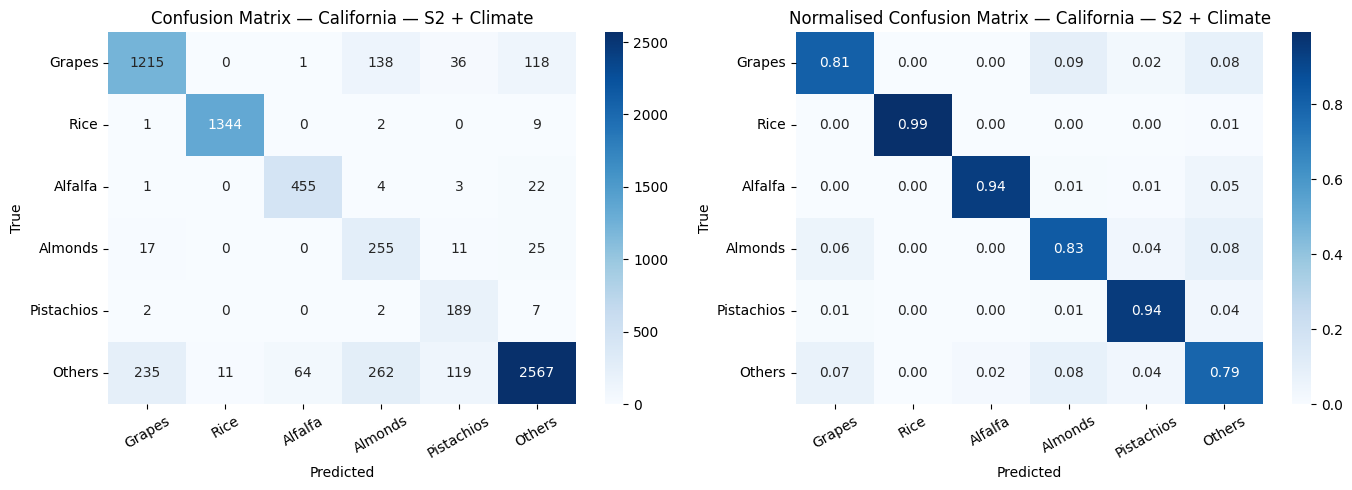


  — Learned Gate Values (mean ± std over test set) —
  Climate        : 0.703 ± 0.304  |██████████████

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_california_S2_plus_Climate.keras

State: California  |  Config: S2 + Soil
Covariates: 3  ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
  Single-gate mode (['Soil'])
Parameters: 128,002
Epoch 1/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6395 - loss: 1.1290 - val_accuracy: 0.2478 - val_loss: 1.7762 - learning_rate: 0.0010
Epoch 2/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8141 - loss: 0.7613 - val_accuracy: 0.4038 - val_loss: 1.4578 - learning_rate: 0.0010
Epoch 3/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8440 - loss: 0.6619 - val_accuracy: 0.5945 - val_loss: 1.1764 - learning_rate: 0.0010
Epoch 4/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8592 - loss: 0.6020 - val_accuracy: 0.7314 - val_loss: 0.9326 - learning_rate: 0.0010
Epoch 5/

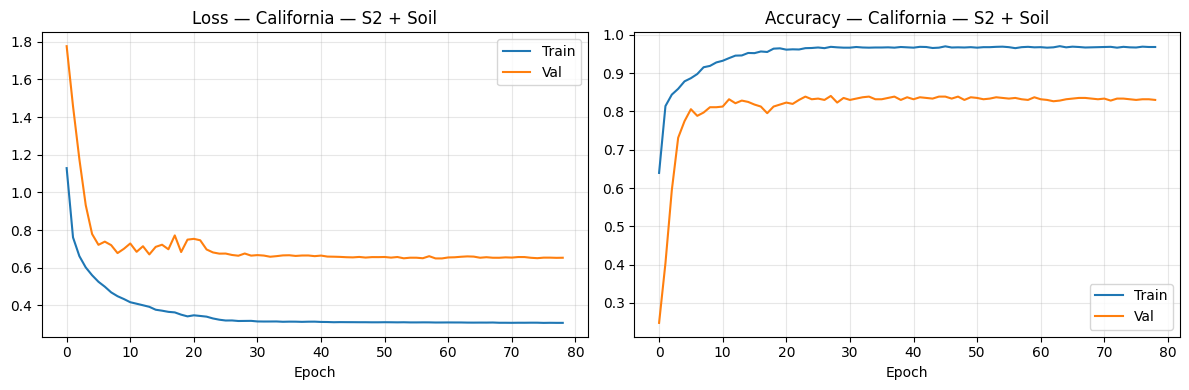


--- California — S2 + Soil Test Results ---
OA=0.8481  Kappa=0.7909  F1-macro=0.7995
              precision    recall  f1-score   support

      Grapes       0.82      0.81      0.81      1508
        Rice       0.99      0.99      0.99      1356
     Alfalfa       0.82      0.94      0.88       485
     Almonds       0.38      0.77      0.51       308
  Pistachios       0.67      0.86      0.75       200
      Others       0.92      0.80      0.86      3258

    accuracy                           0.85      7115
   macro avg       0.77      0.86      0.80      7115
weighted avg       0.87      0.85      0.86      7115



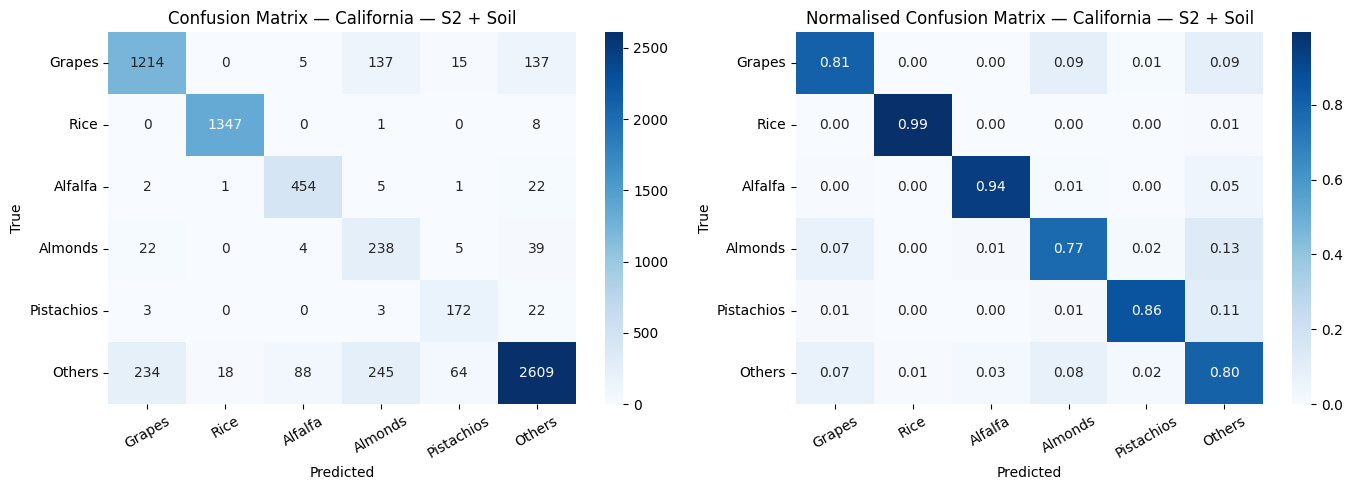


  — Learned Gate Values (mean ± std over test set) —
  Soil           : 0.158 ± 0.175  |███

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_california_S2_plus_Soil.keras

State: California  |  Config: S2 + Topography
Covariates: 2  ['topo_elevation_m', 'topo_landform_class']
  Single-gate mode (['Topography'])
Parameters: 128,067
Epoch 1/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.6395 - loss: 1.1304 - val_accuracy: 0.2929 - val_loss: 1.7733 - learning_rate: 0.0010
Epoch 2/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8111 - loss: 0.7596 - val_accuracy: 0.4125 - val_loss: 1.4802 - learning_rate: 0.0010
Epoch 3/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8445 - loss: 0.6590 - val_accuracy: 0.6291 - val_loss: 1.1408 - learning_rate: 0.0010
Epoch 4/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.8592 - loss: 0.6031 - val_accuracy: 0.7348 - val_loss: 0.9301 - learning_rate: 0.0010
Epoch 5/200
73/73 ━━━━━━━━━━

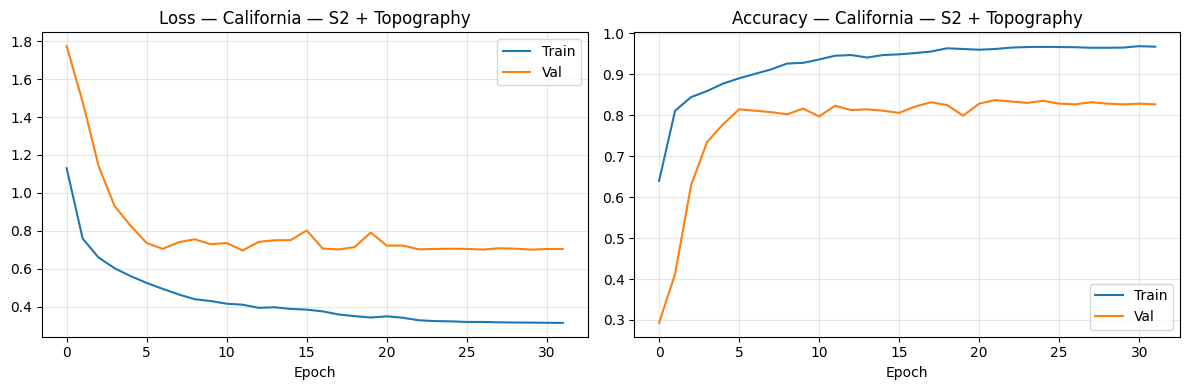


--- California — S2 + Topography Test Results ---
OA=0.8020  Kappa=0.7363  F1-macro=0.7310
              precision    recall  f1-score   support

      Grapes       0.84      0.75      0.79      1508
        Rice       0.99      0.99      0.99      1356
     Alfalfa       0.81      0.94      0.87       485
     Almonds       0.41      0.75      0.53       308
  Pistachios       0.24      0.95      0.38       200
      Others       0.94      0.72      0.82      3258

    accuracy                           0.80      7115
   macro avg       0.71      0.85      0.73      7115
weighted avg       0.88      0.80      0.82      7115



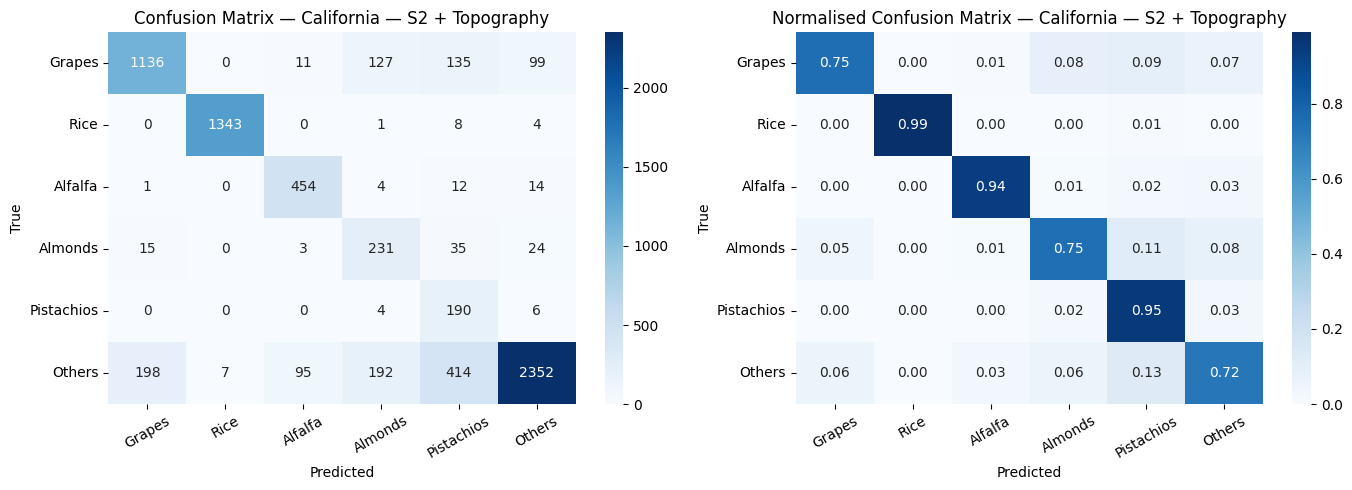


  — Learned Gate Values (mean ± std over test set) —
  Topography     : 0.078 ± 0.104  |█

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_california_S2_plus_Topography.keras

State: California  |  Config: S2 + All
Covariates: 113  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] ...
  Per-group gating: [('Climate', 108), ('Soil', 9), ('Topography', 10)]
Parameters: 129,113
Epoch 1/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.6447 - loss: 1.1482 - val_accuracy: 0.3137 - val_loss: 1.8608 - learning_rate: 0.0010
Epoch 2/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8050 - loss: 0.7886 - val_accuracy: 0.3050 - val_loss: 1.8107 - learning_rate: 0.0010
Epoch 3/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8410 - loss: 0.6803 - val_accuracy: 0.4749 - val_loss: 1.4659 - learning_rate: 0.0010
Epoch 4/200
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8622 - loss: 0.6109 - val_accuracy: 0.6516 - v

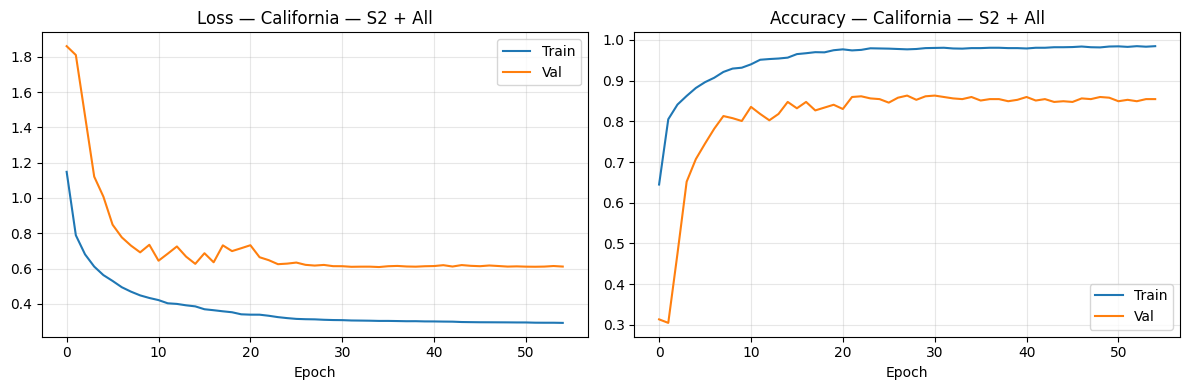


--- California — S2 + All Test Results ---
OA=0.8458  Kappa=0.7903  F1-macro=0.7995
              precision    recall  f1-score   support

      Grapes       0.82      0.83      0.83      1508
        Rice       0.99      0.99      0.99      1356
     Alfalfa       0.83      0.94      0.88       485
     Almonds       0.36      0.86      0.50       308
  Pistachios       0.65      0.86      0.74       200
      Others       0.95      0.78      0.85      3258

    accuracy                           0.85      7115
   macro avg       0.77      0.88      0.80      7115
weighted avg       0.89      0.85      0.86      7115



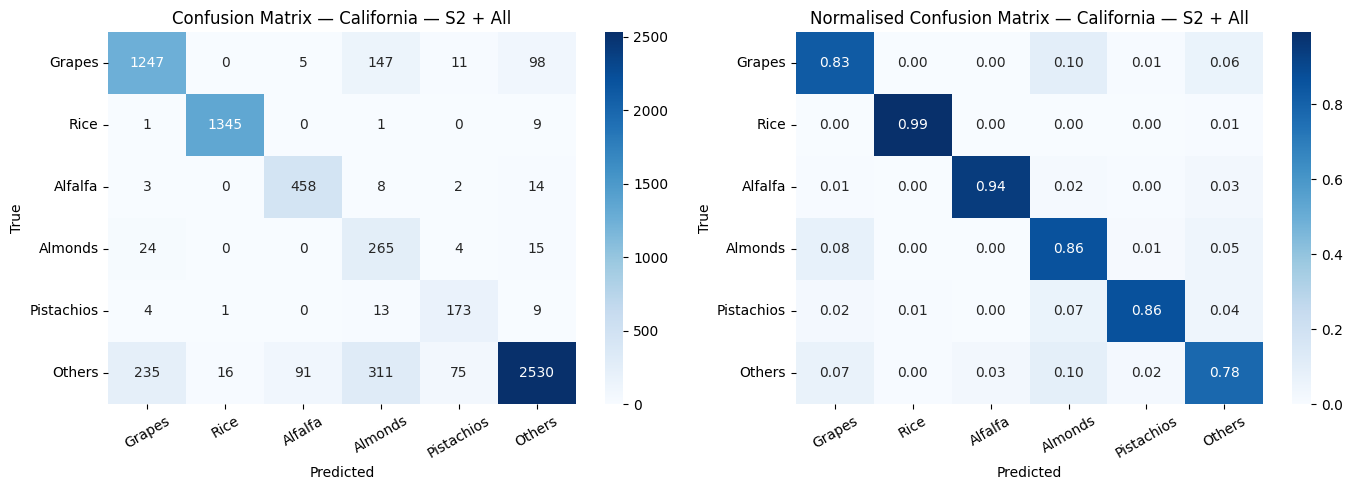


  — Learned Gate Values (mean ± std over test set) —
  Climate        : 0.588 ± 0.398  |███████████
  Soil           : 0.278 ± 0.143  |█████
  Topography     : 0.101 ± 0.022  |██

  Model saved → /content/drive/MyDrive/Colab Notebooks/mctnet_part3_improved_california_S2_plus_All.keras


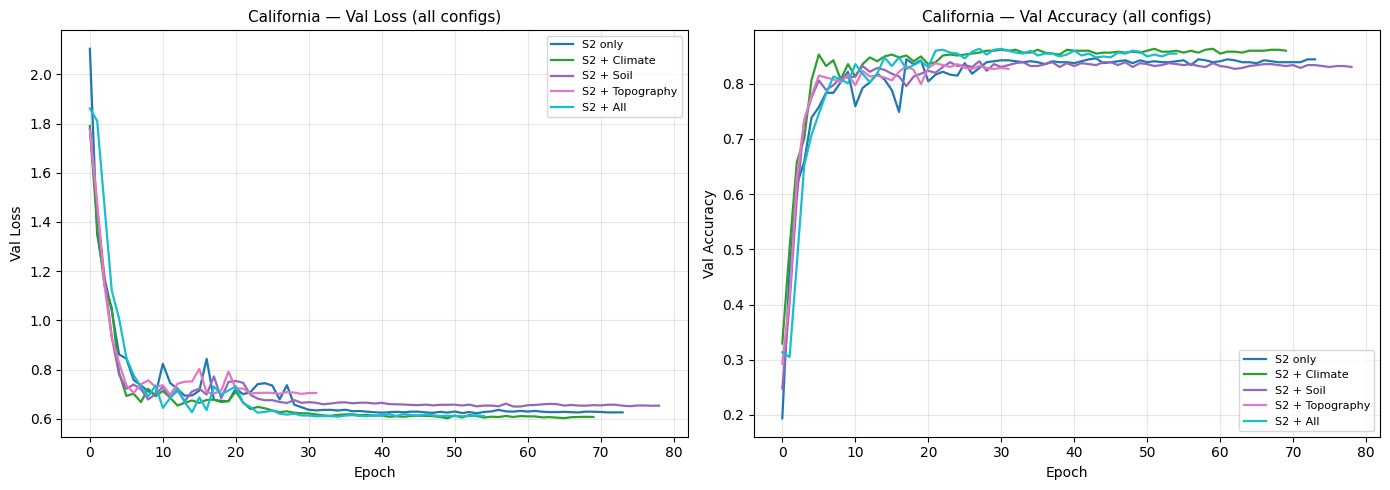


===== California Ablation (Part 3) =====
         Config     OA  Kappa  F1-macro  Params
        S2 only 0.8454 0.7873    0.8017  125080
   S2 + Climate 0.8468 0.7909    0.7950  134437
      S2 + Soil 0.8481 0.7909    0.7995  128002
S2 + Topography 0.8020 0.7363    0.7310  128067
       S2 + All 0.8458 0.7903    0.7995  129113


In [ ]:
ablation_ca_p3 = run_ablation(
    state='California', label_map=CA_LABELS, class_names=ca_classes3,
    full_train=ca_train3, full_val=ca_val3, full_test=ca_test3,
    covar_encoder=ca_enc3, configs=ABLATION_CONFIGS,
    build_baseline_fn=build_mctnet_p3,
    build_cov_fn=build_mctnet_with_covariates_p3,
    part_tag='part3_improved',
)
print('\n===== California Ablation (Part 3) =====')
print(ablation_ca_p3.to_string(index=False))


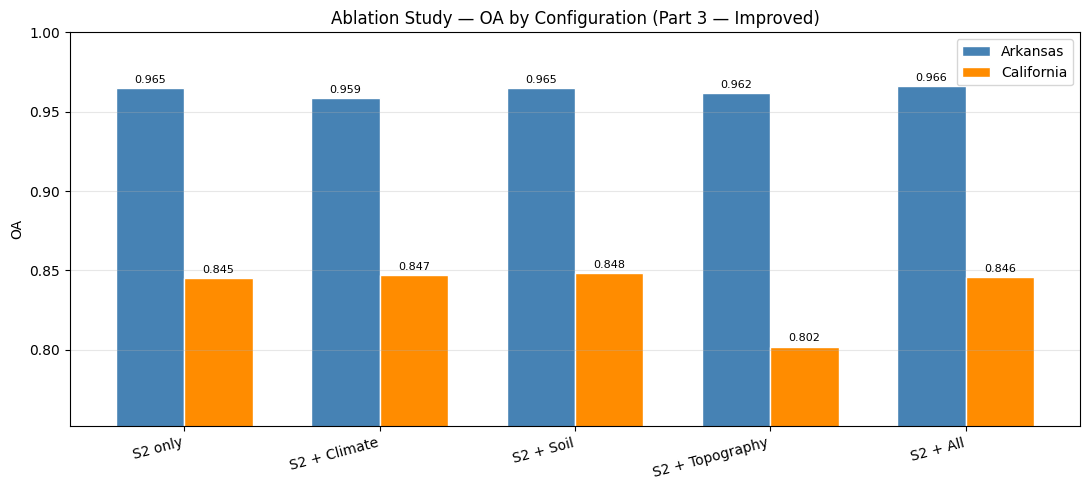

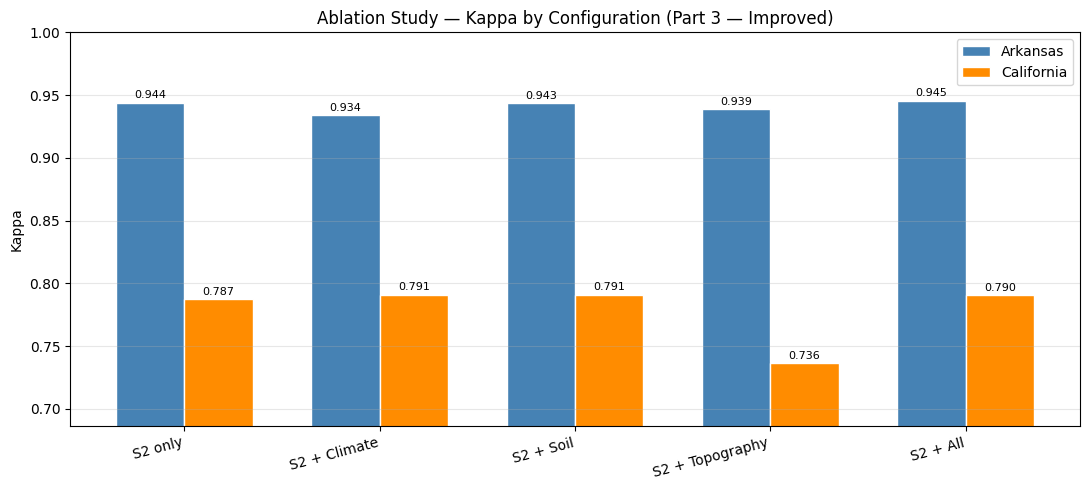

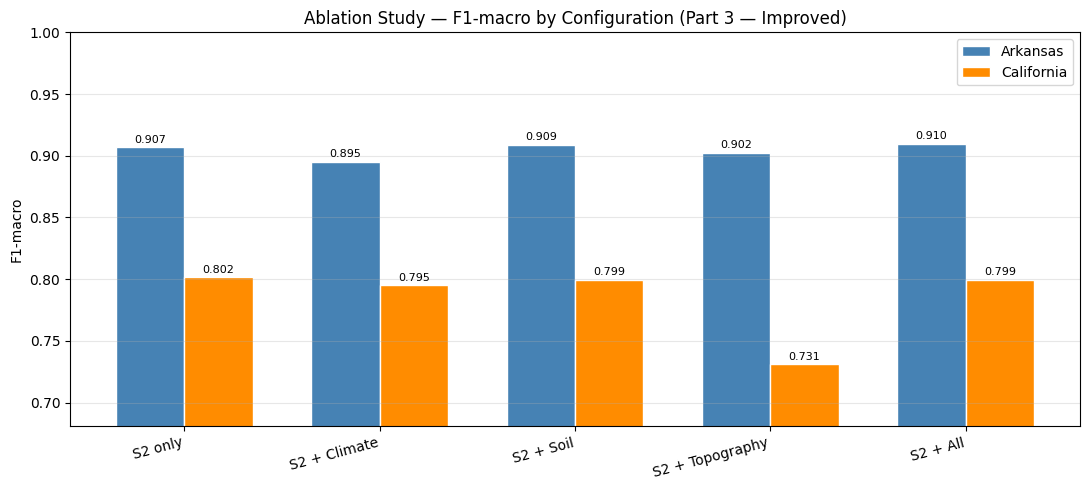


===== Part 3 Combined Ablation Table =====
         Config  OA_AR  Kappa_AR  F1_AR  Params_AR  OA_CA  Kappa_CA  F1_CA  Params_CA
        S2 only 0.9651    0.9439 0.9067     124951 0.8454    0.7873 0.8017     125080
   S2 + Climate 0.9585    0.9338 0.8953     134276 0.8468    0.7909 0.7950     134437
      S2 + Soil 0.9647    0.9434 0.9088     127841 0.8481    0.7909 0.7995     128002
S2 + Topography 0.9617    0.9387 0.9024     127841 0.8020    0.7363 0.7310     128067
       S2 + All 0.9660    0.9453 0.9098     128953 0.8458    0.7903 0.7995     129113

Part 3 results saved.


In [ ]:
for metric in ['OA', 'Kappa', 'F1-macro']:
    plot_ablation_summary(ablation_ar_p3, ablation_ca_p3, metric, title_suffix='(Part 3 — Improved)')

combined_p3 = ablation_ar_p3.rename(columns={
    'OA':'OA_AR','Kappa':'Kappa_AR','F1-macro':'F1_AR','Params':'Params_AR'
}).merge(ablation_ca_p3.rename(columns={
    'OA':'OA_CA','Kappa':'Kappa_CA','F1-macro':'F1_CA','Params':'Params_CA'
}), on='Config')
print('\n===== Part 3 Combined Ablation Table =====')
print(combined_p3.to_string(index=False))


ablation_ar_p3.to_csv(os.path.join(FOLDER, 'ablation_arkansas_part3_improved.csv'), index=False)
ablation_ca_p3.to_csv(os.path.join(FOLDER, 'ablation_california_part3_improved.csv'), index=False)
combined_p3.to_csv(os.path.join(FOLDER, 'ablation_combined_part3_improved.csv'), index=False)
print('\nPart 3 results saved.')
